# The Isotypic Bottleneck: Why Rank Collapse Predicts Grokking on Groups but Not on Parity

**Reproducibility package for a NeurReps 2026 Proceedings Track submission.**

This notebook is adapted from a generic NeurIPS-style experiment template. A few sections of that
template don't apply to this project and have been retargeted rather than filled in mechanically:

- **No external dataset download** (Section 6) — both task families (modular arithmetic, sparse
  parity) are synthetic algorithmic tasks generated on the fly from a seed, as is standard in the
  grokking literature. "Dataset" below means *task generation*, not download.
- **No classification/regression/generation metric suite** (Section 8) — the outcome variable here
  is *when* a precursor signal fires relative to the grokking transition, not predictive accuracy on
  a held-out real-world benchmark. Train/val accuracy are tracked only to *detect* the grokking
  transition itself.
- **"Baselines" (Section 5) means competing precursor signals**, not pretrained models — there is no
  pretrained model to reuse for tiny synthetic algorithmic tasks trained from random init.
- The fault-tolerance section is implemented at the scale this project actually needs: a training
  checkpoint + resume per run, and cached per-run metric logs. The full dataset/feature/embedding
  cache hierarchy from the template doesn't apply since there's no separate feature-extraction step.

**Estimated runtime on a single T4:** the default config (3 primes x 5 seeds for modular arithmetic,
3 k-values x 5 seeds for parity, 5 seeds for S4, plus a weight-decay robustness sweep -- 41
training runs total) should still comfortably finish in a few hours: the first full real run
completed the 35 main runs in ~55 minutes. S4's step budget is now 100000 (see the note in
`CONFIG["group"]` below for why) -- if it still runs to the full ceiling on every seed that adds
roughly 30-35 more minutes worst case, well within a few hours either way. See
`CONFIG["quick_test_mode"]` below to validate the whole pipeline end-to-end in a couple of minutes
first.

**A methodological note surfaced while building this** (see the Method section): the standard
entropy-based "effective rank" definition (Roy & Vetterli 2007) turned out to be substantially more
sensitive to small-magnitude ambient noise than expected — a participation-ratio formulation is far
more robust and is used as the primary rank statistic here, with the entropy-based version kept only
as a secondary, citable diagnostic. Cross-check this against whatever exact definition your rank-
collapse-grokking paper used before treating the two papers' numbers as directly comparable.

## Section 1 -- Environment setup

In [17]:
# Dependency installation (idempotent -- safe to re-run)
import subprocess, sys

def _pip_install(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=True)

try:
    import scipy, pandas, matplotlib  # noqa: F401
except ImportError:
    _pip_install("scipy", "pandas", "matplotlib")

try:
    import torch  # noqa: F401
except ImportError:
    _pip_install("torch")

print("Dependencies OK.")


Dependencies OK.


In [18]:
# Publication-quality matplotlib defaults, used by every figure in Section 14
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.autolayout": False,
    "pdf.fonttype": 42,   # embed fonts as real text, not paths, in the vector PDF output
    "ps.fonttype": 42,
})
print("Matplotlib configured for publication-quality output (vector PDF, embedded fonts).")


Matplotlib configured for publication-quality output (vector PDF, embedded fonts).


In [19]:
# GPU / CUDA detection, environment fingerprint, deterministic settings
import os, platform, random, json, time, hashlib, math
import numpy as np
import pandas as pd
import torch

REQUIRE_GPU = False  # set True to hard-fail on CPU-only runtimes; False = warn and continue on CPU

def detect_environment():
    info = {}
    info["python_version"] = platform.python_version()
    info["os"] = platform.platform()
    info["torch_version"] = torch.__version__
    info["cuda_available"] = torch.cuda.is_available()
    info["cuda_version"] = torch.version.cuda if torch.cuda.is_available() else None
    info["gpu_name"] = torch.cuda.get_device_name(0) if torch.cuda.is_available() else None
    info["gpu_memory_gb"] = (
        round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2) if torch.cuda.is_available() else None
    )
    import numpy, pandas, scipy, matplotlib
    info["numpy_version"] = numpy.__version__
    info["pandas_version"] = pandas.__version__
    info["scipy_version"] = scipy.__version__
    info["matplotlib_version"] = matplotlib.__version__
    # Platform detection: Colab vs Kaggle vs local, needed for the download step. Kaggle checked
    # FIRST and via filesystem/env markers, not the google.colab import: a real run showed
    # `import google.colab` succeeding while writing to /kaggle/working/, i.e. that import alone
    # isn't a reliable Colab signal (Kaggle apparently ships enough of a compatibility stub for it
    # to succeed). /kaggle/working existing is a much harder signal to false-positive on.
    info["runtime"] = "unknown"
    if os.environ.get("KAGGLE_KERNEL_RUN_TYPE") or os.path.exists("/kaggle/working"):
        info["runtime"] = "kaggle"
    else:
        try:
            import google.colab  # noqa: F401
            info["runtime"] = "colab"
        except ImportError:
            info["runtime"] = "local"
    return info

ENV_INFO = detect_environment()
for k, v in ENV_INFO.items():
    print(f"{k:20s}: {v}")

if not ENV_INFO["cuda_available"]:
    msg = ("No CUDA GPU detected. All experiments below will still run (these are small toy models) "
           "but noticeably slower, and the ~1-3h runtime estimate assumes a T4. "
           "On Kaggle: enable an accelerator in Notebook Settings -> Accelerator -> GPU T4 x2. "
           "On Colab: Runtime -> Change runtime type -> T4 GPU.")
    print("\nWARNING:", msg)
    if REQUIRE_GPU:
        raise RuntimeError("REQUIRE_GPU=True and no GPU was detected. " + msg)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nUsing device:", DEVICE)


python_version      : 3.12.13
os                  : Linux-6.12.90+-x86_64-with-glibc2.35
torch_version       : 2.10.0+cu128
cuda_available      : True
cuda_version        : 12.8
gpu_name            : Tesla T4
gpu_memory_gb       : 15.64
numpy_version       : 2.0.2
pandas_version      : 2.3.3
scipy_version       : 1.16.3
matplotlib_version  : 3.10.0
runtime             : kaggle

Using device: cuda


In [20]:
# Global seeding + deterministic execution
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True, warn_only=True)

set_seed(0)
print("Global seed set to 0 (per-run seeds are set again inside each training call).")


Global seed set to 0 (per-run seeds are set again inside each training call).


In [21]:
# Output directory structure. Subdirectories are the ones this project actually
# populates -- the template's generic features/embeddings/predictions cache dirs
# are omitted because there's no separate feature-extraction or inference-serving
# stage here (see the adaptation note in the title cell).
from pathlib import Path

OUT = Path("outputs")
DIRS = {
    "cache_datasets": OUT / "cache" / "datasets",
    "cache_metrics":  OUT / "cache" / "metric_logs",
    "checkpoints":    OUT / "checkpoints",
    "configs":        OUT / "configs",
    "figures":        OUT / "figures",
    "tables":         OUT / "tables",
    "logs":           OUT / "logs",
    "metrics":        OUT / "metrics",
    "environment":    OUT / "environment",
    "summaries":      OUT / "summaries",
}
for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

with open(DIRS["environment"] / "environment.json", "w") as f:
    json.dump(ENV_INFO, f, indent=2)

print("Created output directories under", OUT.resolve())
for name, d in DIRS.items():
    print(f"  {name:16s} -> {d}")


Created output directories under /kaggle/working/outputs
  cache_datasets   -> outputs/cache/datasets
  cache_metrics    -> outputs/cache/metric_logs
  checkpoints      -> outputs/checkpoints
  configs          -> outputs/configs
  figures          -> outputs/figures
  tables           -> outputs/tables
  logs             -> outputs/logs
  metrics          -> outputs/metrics
  environment      -> outputs/environment
  summaries        -> outputs/summaries


## Section 2 -- Configuration

One central `CONFIG` dict. Every experiment below reads from this and nothing is hard-coded
downstream. Defaults are literature-informed starting points:

- Modular addition hyperparameters follow the standard grokking setup (Power et al. 2022; Nanda et
  al. 2023): AdamW, weight decay ~1-2, ~30-40% train split, d_model=128.
- Sparse parity hyperparameters follow Barak et al. (2022): parity is markedly harder to grok than
  modular addition (SQ-hardness), so it gets a larger step budget by default.

**Sample-size choices are deliberate, not defaults left untouched.** Two things are non-negotiable
given the statistics used later: (1) H1 is a Pearson correlation across primes -- 2 primes makes that
test degenerate (a 2-point "correlation" is trivially +-1 regardless of the data), so
`primes` has 3 entries minimum. (2) The one-sided Wilcoxon signed-rank test used for H2 has a hard
floor on the smallest p-value it can ever report: 1/2^n. At n=3 seeds that floor is 0.125 -- no true
effect, however large, could cross even an uncorrected alpha=0.05 threshold, let alone the
Bonferroni-adjusted one used here. `seeds` therefore defaults to 5, giving each individual
prime/k condition a floor of 1/32=0.031, and considerably more once conditions are pooled (Section 8).

Set `CONFIG["quick_test_mode"] = True` for a ~2 minute smoke test of the entire pipeline (tiny
primes, tiny n, few hundred steps -- will NOT show real grokking, only proves nothing crashes and
every downstream cell has something to consume). Set it to `False` for the real run.

In [64]:
CONFIG = {
    "quick_test_mode": False,   # True = fast smoke test; False = full experiment (set before the real run)
    "resume": True,            # reuse existing checkpoints/logs when present
    "overwrite": False,        # if True, force regeneration of every artifact regardless of cache

    "seeds": [0, 1, 2, 3, 4],

    "modular": {
        "primes": [61, 97, 113],  # >=3 required: H1 is a correlation test, and a 2-point
                                   # "correlation" is trivially +-1 regardless of the data
        "train_frac": 0.4,
        "d_model": 128, "n_heads": 4, "n_layers": 1, "d_mlp": 512,
        "lr": 1e-3, "weight_decay": 2.0, "betas": [0.9, 0.98],
        "max_steps": 20000,
        "grok_acc_threshold": 0.95,
    },

    "parity": {
        # multiple k values at fixed n_bits, so the "no collapse" pattern's generality across
        # sparsity levels falls out of the main run instead of needing a separate ablation sweep
        "configs": [
            {"n_bits": 40, "k": 2, "num_samples": 3000, "train_frac": 0.7},
            {"n_bits": 40, "k": 3, "num_samples": 4000, "train_frac": 0.7},
            {"n_bits": 40, "k": 4, "num_samples": 6000, "train_frac": 0.7},
        ],
        "width": 200,
        "lr": 1e-3, "weight_decay": 0.7, "betas": [0.9, 0.98],
        "max_steps": 40000,
        "grok_acc_threshold": 0.95,
    },

    "group": {
        # S4 (order 24): non-abelian, irreps of dims 1,1,2,3,3 -- see the note in Section 4.1.
        # Same architecture/hyperparameters as modular arithmetic for direct comparability;
        # only 576 total (g,h) pairs exist, so train_frac is higher than the modular sweep uses.
        # max_steps=100000, not 20000: the first real run showed all 5 seeds stuck at 5.6-10.8%
        # val accuracy (barely above the 4.2% chance rate for 24-way classification) after the
        # full 20000-step budget, never triggering early stopping -- i.e. never grokking at all.
        # Modular arithmetic needed up to 17000 steps at this same architecture/step-logging
        # cadence; nothing establishes 20000 is enough for a non-abelian group with no obvious
        # shortcut, so this is the single, well-motivated change (more time, nothing else) rather
        # than changing weight_decay/lr/train_frac at the same time and confounding what fixed it.
        # Early stopping still cuts this short automatically once grokking actually happens, so a
        # generous ceiling costs nothing if convergence turns out to need far fewer steps.
        "name": "S4",
        "train_frac": 0.6,
        "d_model": 128, "n_heads": 4, "n_layers": 1, "d_mlp": 512,
        "lr": 1e-3, "weight_decay": 2.0, "betas": [0.9, 0.98],
        "max_steps": 100000,
        "grok_acc_threshold": 0.95,
    },

    "group_d4": {
        # D4 (order 8): non-abelian, but 1/3 the elements and 1/9 the total pairs of S4, and a
        # DIFFERENT irrep-dimension profile (1,1,1,1,2 vs S4's 1,1,2,3,3) -- see Section 4.1c.
        "name": "D4",
        "train_frac": 0.6,
        "d_model": 128, "n_heads": 4, "n_layers": 1, "d_mlp": 512,
        "lr": 1e-3, "weight_decay": 2.0, "betas": [0.9, 0.98],
        "max_steps": 100000,
        "grok_acc_threshold": 0.95,
    },

    "nonabelian_wd_grid": {
        # Disentangles WHY S4 doesn't grok: group size/complexity, or the weight-decay recipe
        # carried over unchanged from modular arithmetic? Predictions stated before running:
        # D4 groks regardless of wd, S4 fails at every value -> size is the blocker.
        # Neither groks at any tested value -> something more structural (architecture/depth).
        # S4 groks at an alternate wd -> wd=2.0 specifically was wrong for non-abelian tasks.
        # D4 already gets a wd=2.0 point for direct comparison with S4's existing data; S4 gets
        # two values we don't have yet (already have wd=2.0 from the main run).
        # d4_wd_values deliberately does NOT include 2.0: D4's own main run (CONFIG["group_d4"])
        # already trains at wd=2.0, so including it here would silently retrain the identical
        # condition under a different run_id and waste compute for zero new information.
        "d4_wd_values": [1.0],
        "s4_wd_values": [0.5, 1.0],
    },

    "eval_every": 200,        # steps between metric snapshots
    "ckpt_every": 2000,       # steps between checkpoint saves
    "early_stop_stable_evals": 5,   # consecutive evals above threshold before declaring "grokked + stable"
    "early_stop_patience_evals": 15,  # extra evals to run after stability, then stop (saves compute)

    "walsh_max_degree": 2,    # degree bound for the Walsh-alignment score (raise to 3 only for small n)
    "fourier_top_k": 4,       # number of frequencies for the modular-arithmetic Fourier concentration score

    "bootstrap_n": 10000,
    "bootstrap_ci": 0.95,
    "alpha": 0.05,

    "num_workers": 0,         # full-batch / in-memory training, no dataloader worker processes needed
    "mixed_precision": False,  # models are tiny; AMP would add overhead, not save time, at this scale
}

# quick_test_mode overrides -- small enough to finish in ~1-2 minutes on CPU, purely to validate the pipeline
if CONFIG["quick_test_mode"]:
    CONFIG["seeds"] = [0, 1]
    CONFIG["modular"]["primes"] = [17]
    CONFIG["modular"]["max_steps"] = 600
    CONFIG["parity"]["configs"] = [{"n_bits": 14, "k": 3, "num_samples": 2000, "train_frac": 0.7}]
    CONFIG["parity"]["max_steps"] = 1200
    CONFIG["group"]["max_steps"] = 600
    CONFIG["group_d4"]["max_steps"] = 600
    CONFIG["nonabelian_wd_grid"]["d4_wd_values"] = [1.0]
    CONFIG["nonabelian_wd_grid"]["s4_wd_values"] = [1.0]
    CONFIG["eval_every"] = 50
    CONFIG["ckpt_every"] = 200
    CONFIG["early_stop_stable_evals"] = 2
    CONFIG["early_stop_patience_evals"] = 3

def config_hash(cfg: dict) -> str:
    '''Stable hash of a config sub-dict, used to invalidate stale checkpoints.'''
    return hashlib.sha256(json.dumps(cfg, sort_keys=True).encode()).hexdigest()[:12]

with open(DIRS["configs"] / "config.json", "w") as f:
    json.dump(CONFIG, f, indent=2)

print(json.dumps(CONFIG, indent=2))
if CONFIG["quick_test_mode"]:
    print("\n*** quick_test_mode=True: this run will NOT show real grokking, it only smoke-tests the pipeline. ***")
    print("*** Set CONFIG['quick_test_mode']=False and re-run from Section 2 for the real experiment. ***")


{
  "quick_test_mode": false,
  "resume": true,
  "overwrite": false,
  "seeds": [
    0,
    1,
    2,
    3,
    4
  ],
  "modular": {
    "primes": [
      61,
      97,
      113
    ],
    "train_frac": 0.4,
    "d_model": 128,
    "n_heads": 4,
    "n_layers": 1,
    "d_mlp": 512,
    "lr": 0.001,
    "weight_decay": 2.0,
    "betas": [
      0.9,
      0.98
    ],
    "max_steps": 20000,
    "grok_acc_threshold": 0.95
  },
  "parity": {
    "configs": [
      {
        "n_bits": 40,
        "k": 2,
        "num_samples": 3000,
        "train_frac": 0.7
      },
      {
        "n_bits": 40,
        "k": 3,
        "num_samples": 4000,
        "train_frac": 0.7
      },
      {
        "n_bits": 40,
        "k": 4,
        "num_samples": 6000,
        "train_frac": 0.7
      }
    ],
    "width": 200,
    "lr": 0.001,
    "weight_decay": 0.7,
    "betas": [
      0.9,
      0.98
    ],
    "max_steps": 40000,
    "grok_acc_threshold": 0.95
  },
  "group": {
    "name": "S4",
    

## Section 3 -- Problem definition

**Motivation.** Effective-rank collapse in hidden representations is one of the earliest known
precursors to grokking, but it is an empirical heuristic of unknown scope: it is already known to
fail, unexplained, on k-sparse parity tasks.

**Core hypothesis.** The scope of rank collapse is governed by representation theory. If a task's
minimal generalizing circuit lies entirely in the isotypic components of irreducibles
$\rho_1,\dots,\rho_m$ (real dimensions $d_1,\dots,d_m$, multiplicities $n_1,\dots,n_m$), then

$$\mathrm{rank}(\Phi) \le \sum_i n_i d_i \qquad \text{(Lemma -- proved below, cell "isotypic bound sanity check")}$$

For modular addition over $\mathbb{Z}_p$ ($p$ odd prime), the nontrivial real irreducibles are
2-dimensional rotation representations; if only a handful of frequencies are needed, the bound is
small ($\approx 2c \ll d_{\text{model}}$) and collapse is sharp. For $k$-sparse parity, the relevant
symmetry is the elementary abelian group $(\mathbb{Z}/2)^n$, whose irreducibles (Walsh characters)
are all 1-dimensional; per SQ-hardness results (Barak et al. 2022) a bounded-width circuit realizing
the degree-$k$ target is not expected to compress into a shared low-rank subspace the way the
rotation-based solution does, even though the *target function's own* spectral support is a single
character. **This second half is a conjecture motivated by prior computational-hardness results, not
a theorem** -- the isotypic bound only gives a sufficient condition for collapse, not a necessary one
(a rank-1 "linear-sum-then-sharp-nonlinearity" solution to parity exists in principle; the claim is
that gradient descent does not find it, which is an empirical question these experiments test).

**H1 (scope).** Collapsed-rank magnitude on group-composition tasks correlates with the theoretical
isotypic bound $\sum_i n_i d_i$, not with $d_{\text{model}}$.

**H2 (fix).** A degree-bounded Walsh/character-alignment score shows a clean pre-grokking rise on
sparse parity, where raw rank shows none.

**Falsification.** H1 fails if no such correlation holds across a sweep of group tasks. H2 fails if
the Walsh score does not lead grokking on parity by a margin comparable to precursors reported
elsewhere in this literature (hundreds to low thousands of steps).

## Section 4 -- Method

### 4.1 Task generation

Both tasks are generated deterministically from a seed -- no download, no external data. Modular
addition uses the standard `[a, b, EQUALS]` -> `(a+b) mod p` framing (Nanda et al. 2023). Sparse
parity uses $\{-1,+1\}$ inputs (the sign convention Boolean-Fourier / Walsh analysis is built on) so
the alignment-score machinery in 4.3 applies directly. A third task, S4 group composition, is added
below (4.1b) specifically to strengthen H1: Z_p's nontrivial irreps are all 2-dimensional, so
"predicted bound" there is collinear with "number of active irreps" -- it can't distinguish a
dimension-weighted account from a simple count. S4's irreps have dimensions 1, 1, 2, 3, 3, so its
predicted bound depends on *which* irreps are active, not just how many -- a strictly stronger test
of the actual lemma (rank <= sum n_i d_i), not a repeat of the same test on a bigger group.

In [65]:
def make_modular_addition_dataset(p: int, train_frac: float, seed: int):
    '''All pairs (a,b) in Z_p x Z_p -> (a+b) mod p. Token p is the '=' separator;
    sequence per example is [a, b, EQUALS]. Label read off the logits at the final position.'''
    g = torch.Generator().manual_seed(seed)
    a = torch.arange(p).repeat_interleave(p)
    b = torch.arange(p).repeat(p)
    y = (a + b) % p
    eq = torch.full_like(a, fill_value=p)
    X = torch.stack([a, b, eq], dim=1)
    n = X.shape[0]
    perm = torch.randperm(n, generator=g)
    n_train = int(train_frac * n)
    train_idx, val_idx = perm[:n_train], perm[n_train:]
    return (X[train_idx], y[train_idx]), (X[val_idx], y[val_idx]), p + 1


def make_sparse_parity_dataset(n_bits: int, k: int, num_samples: int, train_frac: float, seed: int):
    '''k-sparse parity of n_bits bits, inputs in {-1,+1}^n_bits. The relevant subset S is fixed
    by the seed and NOT exposed to the model or to the alignment-score estimator (see 4.3) --
    it's used only to sanity-check the generator itself.'''
    rng = np.random.default_rng(seed)
    S = rng.choice(n_bits, size=k, replace=False)
    X01 = rng.integers(0, 2, size=(num_samples, n_bits))
    Xpm = 1 - 2 * X01
    parity_pm = np.prod(Xpm[:, S], axis=1)
    y = (parity_pm < 0).astype(np.int64)
    X = torch.tensor(Xpm, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.long)
    n_train = int(train_frac * num_samples)
    return (X[:n_train], y[:n_train]), (X[n_train:], y[n_train:]), S


# self-test: label really is the parity of the sampled subset S
_Xtr, _ytr = make_sparse_parity_dataset(12, 3, 500, 0.7, seed=0)[0]
_S = make_sparse_parity_dataset(12, 3, 500, 0.7, seed=0)[2]
_recon = (np.prod(_Xtr.numpy()[:, _S], axis=1) < 0).astype(np.int64)
assert (_recon == _ytr.numpy()).all(), "parity dataset generator self-test failed"
print("Task generators OK (self-test passed).")


Task generators OK (self-test passed).


### 4.1b S4: group theory and task generation

S4 (order 24) as permutations of (0,1,2,3), composition = function composition. Character table
hard-coded from the standard reference tables (Fulton & Harris; Serre) and verified two
independent ways below -- both Burnside's sum-of-squares identity and full row-orthogonality,
since a hand-transcribed character table is exactly the kind of thing that's easy to get subtly
wrong and hard to notice if it is.

In [66]:
import itertools
from collections import Counter

S4_ELEMENTS = list(itertools.permutations(range(4)))  # 24 tuples; index 0 = identity by construction
S4_INDEX = {perm: i for i, perm in enumerate(S4_ELEMENTS)}

def s4_compose(g, h):
    '''g o h: apply h first, then g.'''
    return tuple(g[h[x]] for x in range(4))

def s4_cycle_type(perm):
    seen = [False] * 4
    lengths = []
    for start in range(4):
        if seen[start]:
            continue
        length, x = 0, start
        while not seen[x]:
            seen[x] = True; x = perm[x]; length += 1
        lengths.append(length)
    return tuple(sorted(lengths))

_CYCLE_TYPE_TO_CLASS = {(1,1,1,1): "e", (1,1,2): "transposition", (2,2): "double_transposition",
                         (1,3): "three_cycle", (4,): "four_cycle"}
S4_CLASS_OF = {perm: _CYCLE_TYPE_TO_CLASS[s4_cycle_type(perm)] for perm in S4_ELEMENTS}

_class_sizes = Counter(S4_CLASS_OF.values())
_expected_sizes = {"e": 1, "transposition": 6, "double_transposition": 3, "three_cycle": 8, "four_cycle": 6}
assert _class_sizes == _expected_sizes, f"conjugacy class sizes wrong: {_class_sizes}"

S4_IRREPS = ["trivial", "sign", "two_dim", "standard", "standard_sign"]
S4_IRREP_DIMS = {"trivial": 1, "sign": 1, "two_dim": 2, "standard": 3, "standard_sign": 3}
S4_CHARACTER_TABLE = {
    "trivial":       {"e": 1, "transposition": 1,  "double_transposition": 1,  "three_cycle": 1,  "four_cycle": 1},
    "sign":          {"e": 1, "transposition": -1, "double_transposition": 1,  "three_cycle": 1,  "four_cycle": -1},
    "two_dim":       {"e": 2, "transposition": 0,  "double_transposition": 2,  "three_cycle": -1, "four_cycle": 0},
    "standard":      {"e": 3, "transposition": 1,  "double_transposition": -1, "three_cycle": 0,  "four_cycle": -1},
    "standard_sign": {"e": 3, "transposition": -1, "double_transposition": -1, "three_cycle": 0,  "four_cycle": 1},
}

# check 1: Burnside / Peter-Weyl -- sum of squared irrep dimensions must equal |G|
assert sum(d**2 for d in S4_IRREP_DIMS.values()) == 24, "sum(dim^2) must equal |S4|=24"
# check 2: full row-orthogonality with class-size weighting (a much stronger check than check 1
# alone -- catches sign errors and transposed entries that check 1 would miss)
for _r1 in S4_IRREPS:
    for _r2 in S4_IRREPS:
        _inner = sum(_expected_sizes[c] * S4_CHARACTER_TABLE[_r1][c] * S4_CHARACTER_TABLE[_r2][c]
                     for c in _expected_sizes)
        assert _inner == (24 if _r1 == _r2 else 0), f"row orthogonality failed for ({_r1},{_r2}): {_inner}"
print("S4 character table verified: sum(dim^2)=24, all row-orthogonality relations hold exactly.")

def make_s4_dataset(train_frac: float, seed: int):
    '''All 24x24=576 pairs (g,h) -> g o h. Token 0..23 = S4 elements (S4_INDEX order), token
    24 = EQUALS. Sequence [g_tok, h_tok, EQUALS].'''
    g = torch.arange(24).repeat_interleave(24)
    h = torch.arange(24).repeat(24)
    y = torch.tensor([S4_INDEX[s4_compose(S4_ELEMENTS[gi], S4_ELEMENTS[hi])]
                       for gi, hi in zip(g.tolist(), h.tolist())])
    eq = torch.full_like(g, fill_value=24)
    X = torch.stack([g, h, eq], dim=1)
    n = X.shape[0]
    gen = torch.Generator().manual_seed(seed)
    perm = torch.randperm(n, generator=gen)
    n_train = int(train_frac * n)
    train_idx, val_idx = perm[:n_train], perm[n_train:]
    return (X[train_idx], y[train_idx]), (X[val_idx], y[val_idx]), 25

# self-test: group axioms + label correctness (same discipline as the other two generators)
import random as _random
_rng = _random.Random(0)
for _ in range(200):
    _a, _b, _c = (_rng.choice(S4_ELEMENTS) for _ in range(3))
    assert s4_compose(s4_compose(_a, _b), _c) == s4_compose(_a, s4_compose(_b, _c)), "associativity failed"
_id = (0, 1, 2, 3)
for _g in S4_ELEMENTS:
    assert s4_compose(_id, _g) == _g and s4_compose(_g, _id) == _g
(_Xtr_s4, _ytr_s4), _, _ = make_s4_dataset(0.6, seed=0)
for _i in range(5):
    _gi, _hi, _eq = _Xtr_s4[_i].tolist()
    assert _eq == 24
    assert _ytr_s4[_i].item() == S4_INDEX[s4_compose(S4_ELEMENTS[_gi], S4_ELEMENTS[_hi])]
print("S4 group axioms and dataset labels verified.")


S4 character table verified: sum(dim^2)=24, all row-orthogonality relations hold exactly.
S4 group axioms and dataset labels verified.


### 4.1c D4: a second, smaller non-abelian group

Added specifically to disentangle *why* S4 doesn't grok: is it group size/complexity, or the
weight-decay/lr recipe carried over unchanged from modular arithmetic? D4 (order 8, the symmetries
of a square) is 1/3 the elements and 1/9 the total pairs of S4, AND has a different irrep-dimension
profile (1,1,1,1,2 vs S4's 1,1,2,3,3) -- if it groks, it's a genuine third test point for H1, not a
repeat of S4's shape. Same verification discipline as S4: character table checked two independent
ways, group axioms checked over random triples.

In [67]:
D4_ELEMENTS = [(a, e) for e in (0, 1) for a in range(4)]  # r^a * s^e, a in 0..3, e in {0,1}
D4_INDEX = {g: i for i, g in enumerate(D4_ELEMENTS)}

def d4_compose(g, h):
    '''Standard dihedral semidirect-product composition (s r s^-1 = r^-1).'''
    a, eps = g
    b, delta = h
    return ((a + b) % 4, delta) if eps == 0 else ((a - b) % 4, 1 - delta)

def d4_class_of(g):
    a, eps = g
    if eps == 0:
        return "e" if a == 0 else ("r2" if a == 2 else "r_r3")
    return "s_r2s" if a % 2 == 0 else "rs_r3s"

_expected_sizes_d4 = {"e": 1, "r2": 1, "r_r3": 2, "s_r2s": 2, "rs_r3s": 2}
D4_IRREPS = ["triv", "chi2", "chi3", "chi4", "two_dim"]
D4_IRREP_DIMS = {"triv": 1, "chi2": 1, "chi3": 1, "chi4": 1, "two_dim": 2}
D4_CHARACTER_TABLE = {
    "triv":    {"e": 1, "r2": 1,  "r_r3": 1,  "s_r2s": 1,  "rs_r3s": 1},
    "chi2":    {"e": 1, "r2": 1,  "r_r3": 1,  "s_r2s": -1, "rs_r3s": -1},
    "chi3":    {"e": 1, "r2": 1,  "r_r3": -1, "s_r2s": 1,  "rs_r3s": -1},
    "chi4":    {"e": 1, "r2": 1,  "r_r3": -1, "s_r2s": -1, "rs_r3s": 1},
    "two_dim": {"e": 2, "r2": -2, "r_r3": 0,  "s_r2s": 0,  "rs_r3s": 0},
}

assert sum(d**2 for d in D4_IRREP_DIMS.values()) == 8, "sum(dim^2) must equal |D4|=8"
for _r1 in D4_IRREPS:
    for _r2 in D4_IRREPS:
        _inner = sum(_expected_sizes_d4[c] * D4_CHARACTER_TABLE[_r1][c] * D4_CHARACTER_TABLE[_r2][c]
                     for c in _expected_sizes_d4)
        assert _inner == (8 if _r1 == _r2 else 0), f"row orthogonality failed for ({_r1},{_r2}): {_inner}"
print("D4 character table verified: sum(dim^2)=8, all row-orthogonality relations hold exactly.")

def make_d4_dataset(train_frac: float, seed: int):
    g = torch.arange(8).repeat_interleave(8)
    h = torch.arange(8).repeat(8)
    y = torch.tensor([D4_INDEX[d4_compose(D4_ELEMENTS[gi], D4_ELEMENTS[hi])]
                       for gi, hi in zip(g.tolist(), h.tolist())])
    eq = torch.full_like(g, fill_value=8)
    X = torch.stack([g, h, eq], dim=1)
    n = X.shape[0]
    gen = torch.Generator().manual_seed(seed)
    perm = torch.randperm(n, generator=gen)
    n_train = int(train_frac * n)
    train_idx, val_idx = perm[:n_train], perm[n_train:]
    return (X[train_idx], y[train_idx]), (X[val_idx], y[val_idx]), 9

_rng2 = _random.Random(1)
for _ in range(200):
    _a, _b, _c = (_rng2.choice(D4_ELEMENTS) for _ in range(3))
    assert d4_compose(d4_compose(_a, _b), _c) == d4_compose(_a, d4_compose(_b, _c))
_id4 = (0, 0)
for _g in D4_ELEMENTS:
    assert d4_compose(_id4, _g) == _g and d4_compose(_g, _id4) == _g
(_Xtr_d4, _ytr_d4), _, _ = make_d4_dataset(0.6, seed=0)
for _i in range(5):
    _gi, _hi, _eq = _Xtr_d4[_i].tolist()
    assert _eq == 8
    assert _ytr_d4[_i].item() == D4_INDEX[d4_compose(D4_ELEMENTS[_gi], D4_ELEMENTS[_hi])]
print("D4 group axioms and dataset labels verified.")


D4 character table verified: sum(dim^2)=8, all row-orthogonality relations hold exactly.
D4 group axioms and dataset labels verified.


### 4.2 Models

`TinyTransformer` for modular addition (1-layer decoder-only, hand-rolled rather than
`nn.Transformer` so the residual stream at the final token position is directly accessible for the
rank / Fourier probes -- standard grokking-study architecture, Nanda et al. 2023). `ParityMLP` for
sparse parity (1 hidden ReLU layer; the post-ReLU hidden activations are what gets probed).

In [68]:
import torch.nn as nn
import torch.nn.functional as F

class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_mlp):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(nn.Linear(d_model, d_mlp), nn.GELU(), nn.Linear(d_mlp, d_model))

    def forward(self, x):
        h = self.ln1(x)
        seq_len = x.shape[1]
        causal_mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device), diagonal=1).bool()
        attn_out, _ = self.attn(h, h, h, attn_mask=causal_mask, need_weights=False)
        x = x + attn_out
        x = x + self.mlp(self.ln2(x))
        return x


class TinyTransformer(nn.Module):
    '''1-layer decoder-only transformer for algorithmic tasks. Returns logits at the final
    ('=') position, and optionally the residual stream there for representation probes.'''

    def __init__(self, vocab_size, seq_len, d_model=128, n_heads=4, n_layers=1, d_mlp=512, n_out=None):
        super().__init__()
        n_out = n_out or vocab_size
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Parameter(torch.randn(seq_len, d_model) * 0.02)
        self.blocks = nn.ModuleList([TransformerBlock(d_model, n_heads, d_mlp) for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(d_model)
        self.unembed = nn.Linear(d_model, n_out, bias=False)

    def forward(self, idx, return_resid=False):
        x = self.tok_emb(idx) + self.pos_emb.unsqueeze(0)
        for block in self.blocks:
            x = block(x)
        resid_final = x[:, -1, :]
        logits = self.unembed(self.ln_f(resid_final))
        return (logits, resid_final) if return_resid else logits


class ParityMLP(nn.Module):
    '''1 hidden-layer MLP for k-sparse parity. Post-ReLU hidden activations are the probe point.'''

    def __init__(self, n_bits, width=200, n_classes=2):
        super().__init__()
        self.fc1 = nn.Linear(n_bits, width)
        self.fc2 = nn.Linear(width, n_classes)

    def forward(self, x, return_hidden=False):
        h = F.relu(self.fc1(x))
        logits = self.fc2(h)
        return (logits, h) if return_hidden else logits


print("Model classes defined: TinyTransformer, ParityMLP.")


Model classes defined: TinyTransformer, ParityMLP.


### 4.3 Metrics

Three rank statistics are computed together because **they trade off very differently under ambient
noise** -- this was checked empirically (next cell) rather than assumed. `participation_ratio` is
used as the primary metric for the H1 test; `entropy_rank` (Roy & Vetterli 2007) and `rank99` are
kept as secondary, more standard-but-noisier diagnostics. `fourier_concentration` is the baseline
alignment score for the cyclic task; `walsh_alignment_score` is the new alignment score for parity —
it does **not** require knowing the true relevant bit subset, it sweeps all low-degree Walsh
functions of the inputs.

In [69]:
def effective_rank(activations: torch.Tensor, eps: float = 1e-12) -> dict:
    '''Three rank diagnostics on a [batch, dim] activation matrix (mean-centered first).
    See the robustness demo in the next cell for why participation_ratio is primary.'''
    X = activations - activations.mean(dim=0, keepdim=True)
    if torch.allclose(X, torch.zeros_like(X)):
        return dict(participation_ratio=0.0, entropy_rank=0.0, rank99=0, sigma1=0.0)
    s = torch.linalg.svdvals(X)
    s = s[s > eps]
    if s.numel() == 0:
        return dict(participation_ratio=0.0, entropy_rank=0.0, rank99=0, sigma1=0.0)
    pr = (s.pow(2).sum() ** 2 / s.pow(4).sum()).item()
    p = s / s.sum()
    ent = -(p * torch.log(p)).sum()
    entropy_rank = torch.exp(ent).item()
    sigma1 = s[0].item()
    cum = torch.cumsum(s ** 2, dim=0) / (s ** 2).sum()
    rank99 = int((cum < 0.99).sum().item()) + 1
    return dict(participation_ratio=pr, entropy_rank=entropy_rank, rank99=rank99, sigma1=sigma1)


def fourier_concentration(embed_rows: torch.Tensor, top_k: int) -> float:
    '''embed_rows: [p, d] digit-token embeddings, treated as a length-p cyclic signal per
    dimension. Returns the fraction of total (non-DC) spectral power in the top_k frequencies.'''
    spec = torch.fft.rfft(embed_rows.detach().cpu(), dim=0)
    power = (spec.abs() ** 2).sum(dim=1)
    power_ac = power[1:]
    total = power_ac.sum().item()
    if total <= 0:
        return 0.0
    topk = torch.topk(power_ac, k=min(top_k, power_ac.numel())).values.sum().item()
    return topk / total


def walsh_alignment_score(activations: torch.Tensor, inputs_pm1: torch.Tensor, max_degree: int = 2) -> float:
    '''Fraction of activation variance explained by a linear fit onto the degree-<=max_degree
    Walsh (Boolean Fourier) basis of the inputs, measured OUT OF SAMPLE: fit on the first half of
    the batch, score R^2 on the held-out second half. This matters because the degree-2 basis at
    n_bits=40 has 821 features -- an IN-SAMPLE fit (the original version of this function) reports
    close to 0.5-1.0 on pure noise whenever the feature count is a large fraction of the batch size,
    purely from overfitting, with no real alignment required. Verified empirically: at the configured
    real-run scale, in-sample R^2 on pure noise activations was 0.91 (k=2), 0.68 (k=3), 0.46 (k=4) --
    i.e. the old version would have reported "strong alignment" on parity even with zero real signal.
    Out-of-sample R^2 can legitimately go negative (the fit generalizes worse than the mean) -- that
    is real information, so it is NOT clipped to zero here.'''
    n = inputs_pm1.shape[1]
    dev = inputs_pm1.device
    feats = [torch.ones(inputs_pm1.shape[0], 1, device=dev), inputs_pm1]
    if max_degree >= 2:
        idx_i, idx_j = torch.triu_indices(n, n, offset=1, device=dev)
        feats.append(inputs_pm1[:, idx_i] * inputs_pm1[:, idx_j])
    W = torch.cat(feats, dim=1)
    A = activations - activations.mean(dim=0, keepdim=True)
    N = W.shape[0]
    half = N // 2
    W_fit, W_score = W[:half], W[half:]
    A_fit, A_score = A[:half], A[half:]
    score_var = (A_score ** 2).sum().item()
    if score_var <= 1e-12:
        return 0.0
    sol = torch.linalg.lstsq(W_fit, A_fit).solution
    pred = W_score @ sol
    resid = ((A_score - pred) ** 2).sum().item()
    return 1.0 - resid / score_var


def make_walsh_probe_inputs(n_bits: int, probe_size: int, device) -> torch.Tensor:
    '''Fresh, unlabeled +-1 inputs used ONLY to estimate the Walsh-alignment score -- deliberately
    decoupled from the task's train/val split, so the probe size can be scaled to whatever the
    degree bound needs without changing num_samples (which sets the task's SQ-hardness regime and
    should not be touched for this reason). Resampled fresh at every eval point.'''
    X01 = torch.randint(0, 2, (probe_size, n_bits), device=device)
    return (1 - 2 * X01).float()


def walsh_probe_size(n_bits: int, max_degree: int) -> int:
    '''Empirically-chosen probe size: OOS R^2 on pure noise stays within roughly +-0.1 of zero once
    probe_size//2 is at least ~25x the number of Walsh features being fit (checked directly for
    n_bits=40 at degree 1 and degree 2; see the accompanying writeup for the numbers).'''
    n_feat = 1 + n_bits + (n_bits * (n_bits - 1) // 2 if max_degree >= 2 else 0)
    return max(2500, 25 * n_feat)



def cyclic_isotypic_bound_estimate(embed_rows: torch.Tensor, threshold: float = 0.9) -> int:
    '''Dimension-comparable analogue of fourier_concentration: each nonzero DFT frequency is one
    2-dim real rotation irrep of Z_p. Sort by power, accumulate 2 dims/frequency until `threshold`
    of AC power is explained. Same units as isotypic_bound_estimate (S4 below), which is what
    makes the pooled cross-group H1 test in Section 8 meaningful -- both give a PREDICTED
    DIMENSION, not an arbitrary concentration fraction.'''
    spec = torch.fft.rfft(embed_rows.detach().cpu(), dim=0)
    power = (spec.abs() ** 2).sum(dim=1)
    power_ac = power[1:]
    total = power_ac.sum().item()
    if total <= 0:
        return 0
    sorted_power, _ = torch.sort(power_ac, descending=True)
    cum, bound = 0.0, 0
    for pw in sorted_power:
        bound += 2
        cum += pw.item()
        if cum / total >= threshold:
            break
    return bound


def isotypic_energy_fractions_generic(embed_rows: torch.Tensor, elements, index, compose_fn,
                                        char_table, class_of_fn, irreps, irrep_dims, n: int) -> dict:
    '''Generic version of the character-projection energy decomposition, parameterized by group
    data -- used for both S4 and D4 so the actual math lives in one place, not two near-duplicates.'''
    E = embed_rows.detach().cpu().numpy().astype(np.float64)
    total_energy = float((E ** 2).sum())
    fractions = {}
    for irrep in irreps:
        dim = irrep_dims[irrep]
        proj = np.zeros((n, n))
        for g in elements:
            chi = char_table[irrep][class_of_fn(g)]
            P_g = np.zeros((n, n))
            for h in elements:
                P_g[index[compose_fn(g, h)], index[h]] = 1.0
            proj += chi * P_g
        proj *= dim / n
        projected = proj @ E
        fractions[irrep] = float((projected ** 2).sum()) / total_energy if total_energy > 0 else 0.0
    return fractions


def isotypic_energy_fractions(embed_rows: torch.Tensor) -> dict:
    '''S4 analogue of fourier_concentration, via character-theoretic projection instead of FFT
    (S4 is non-abelian, so there's no DFT to lean on -- this is the actual isotypic decomposition
    machinery the Section 3 lemma is about, applied directly rather than approximated).
    embed_rows: [24, d], row order = S4_ELEMENTS. Returns {irrep: energy fraction}, summing to 1.0
    exactly (verified in the standalone module tests before this ever reached the notebook).'''
    return isotypic_energy_fractions_generic(embed_rows, S4_ELEMENTS, S4_INDEX, s4_compose,
                                              S4_CHARACTER_TABLE, lambda g: S4_CLASS_OF[g],
                                              S4_IRREPS, S4_IRREP_DIMS, 24)


def isotypic_energy_fractions_d4(embed_rows: torch.Tensor) -> dict:
    '''D4 analogue -- same machinery, smaller group. embed_rows: [8, d], row order = D4_ELEMENTS.'''
    return isotypic_energy_fractions_generic(embed_rows, D4_ELEMENTS, D4_INDEX, d4_compose,
                                              D4_CHARACTER_TABLE, d4_class_of,
                                              D4_IRREPS, D4_IRREP_DIMS, 8)


def isotypic_bound_estimate(energy_fractions: dict, irrep_dims: dict = None, threshold: float = 0.9) -> int:
    '''Sort irreps by energy descending, accumulate DIMENSIONS (not counts) until threshold of
    energy is explained. This is the actual dimension-weighted bound from the Section 3 lemma.
    irrep_dims defaults to S4's for backward compatibility with existing call sites; pass
    D4_IRREP_DIMS explicitly for D4 runs.'''
    irrep_dims = irrep_dims if irrep_dims is not None else S4_IRREP_DIMS
    ordered = sorted(energy_fractions.items(), key=lambda kv: -kv[1])
    cum_energy, cum_dim = 0.0, 0
    for irrep, frac in ordered:
        cum_dim += irrep_dims[irrep]
        cum_energy += frac
        if cum_energy >= threshold:
            break
    return cum_dim


def weight_decay_clock(eta: float, lam: float, rho: float = 0.8) -> float:
    '''tau_c = -ln(rho) / (eta*lambda): an HONEST, UNFITTED version of the weight-decay clock
    mechanism. Your NeurIPS 2026 paper's clock uses a separately calibrated multiplier c-bar on
    top of this base form -- that calibration procedure and its data aren't available here, so
    this deliberately does NOT reproduce it. What this tests is the weaker, unfitted claim that
    tau_c is a LOWER BOUND on grokking-related timing (T* > tau_c), not that T* ~ c-bar*tau_c for
    any particular c-bar. rho=0.8 is a plain stated default, not fit to this or any other data.'''
    if not (0 < rho < 1):
        raise ValueError(f"rho must be in (0,1), got {rho}")
    return -math.log(rho) / (eta * lam)


print("Metric functions defined: effective_rank, fourier_concentration, walsh_alignment_score, "
      "cyclic_isotypic_bound_estimate, isotypic_energy_fractions, isotypic_bound_estimate.")


Metric functions defined: effective_rank, fourier_concentration, walsh_alignment_score, cyclic_isotypic_bound_estimate, isotypic_energy_fractions, isotypic_bound_estimate.


**Metric-robustness demonstration.** Before trusting any rank number downstream, verify how each
rank statistic behaves as ambient noise is added to a representation of *known* true dimensionality
(constructed directly from a specified isotypic bound, so the "correct answer" is known exactly).
This is the check that motivated using `participation_ratio` as the primary metric above.

In [70]:
def build_isotypic_signal(num_points, ambient_dim, irrep_dims, multiplicities, seed=0, noise=0.0):
    '''Synthetic representation whose signal lies exactly in a subspace of dimension
    sum(irrep_dims * multiplicities), embedded in a larger ambient space, with optional
    isotropic noise -- used only to sanity-check the rank metrics themselves.'''
    rng = np.random.default_rng(seed)
    true_dim = int(np.sum(np.array(irrep_dims) * np.array(multiplicities)))
    assert true_dim <= ambient_dim
    coeffs = rng.normal(size=(num_points, true_dim))
    basis = rng.normal(size=(true_dim, ambient_dim))
    basis, _ = np.linalg.qr(basis.T)
    basis = basis[:, :true_dim].T
    X = coeffs @ basis
    if noise > 0:
        X = X + noise * rng.normal(size=X.shape)
    return torch.tensor(X, dtype=torch.float32), true_dim


rows = []
for noise in [0.0, 0.02, 0.05, 0.1, 0.2, 0.4]:
    X, true_dim = build_isotypic_signal(500, 64, irrep_dims=[2], multiplicities=[2], seed=2, noise=noise)
    m = effective_rank(X)
    rows.append(dict(noise=noise, true_isotypic_dim=true_dim, **m))

robustness_df = pd.DataFrame(rows)
robustness_df.to_csv(DIRS["tables"] / "metric_robustness_check.csv", index=False)
print(robustness_df.to_string(index=False))
print("\n-> participation_ratio stays close to the true isotypic dimension noticeably longer as noise")
print("   grows than entropy_rank or rank99 do. This is why H1 below is tested on participation_ratio.")

assert robustness_df.loc[robustness_df.noise == 0.1, "participation_ratio"].item() < 10, (
    "participation_ratio should still track the true bound reasonably well at moderate noise"
)


 noise  true_isotypic_dim  participation_ratio  entropy_rank  rank99    sigma1
  0.00                  4             3.955805      3.994036       4 23.423994
  0.02                  4             4.005143     12.640944       4 23.414433
  0.05                  4             4.261938     24.804735      39 23.417009
  0.10                  4             5.223211     38.992485      56 23.467293
  0.20                  4             9.645096     52.281303      61 23.746830
  0.40                  4            28.278542     59.874935      63 25.061724

-> participation_ratio stays close to the true isotypic dimension noticeably longer as noise
   grows than entropy_rank or rank99 do. This is why H1 below is tested on participation_ratio.


**Walsh-score bias check.** The naive (in-sample) version of `walsh_alignment_score` turned out to
have the same failure mode as `entropy_rank` above, for a related reason: at `n_bits=40`, the
degree-<=2 Walsh basis has 821 features, which is a large fraction of any realistic validation-set
size -- an in-sample least-squares fit can partly (or, once features approach the sample count,
almost entirely) fit pure noise, inflating the score with no real alignment behind it. The
out-of-sample version above (fit on half the probe batch, score on the other half) is the fix;
this cell checks it actually removes the bias at the configured scale, on activations with zero
true relationship to the inputs by construction.

In [71]:
_wn_rows = []
for label, deg, n_bits_check in [("degree<=1, n=40", 1, 40), ("degree<=2, n=40", 2, 40)]:
    probe_n = walsh_probe_size(n_bits_check, deg)
    probe_X = make_walsh_probe_inputs(n_bits_check, probe_n, torch.device("cpu"))
    noise_act = torch.randn(probe_n, 200)
    score = walsh_alignment_score(noise_act, probe_X, max_degree=deg)
    _wn_rows.append(dict(config=label, probe_size=probe_n, oos_score_on_pure_noise=score))

walsh_bias_df = pd.DataFrame(_wn_rows)
walsh_bias_df.to_csv(DIRS["tables"] / "walsh_score_bias_check.csv", index=False)
print(walsh_bias_df.to_string(index=False))
print("\nBoth should sit close to 0 (noise has no real Walsh structure by construction). The historical")
print("in-sample numbers at this scale were 0.68 (degree<=2, k=3) and higher -- see the docstring of")
print("walsh_alignment_score for the full before/after table.")
assert walsh_bias_df["oos_score_on_pure_noise"].abs().max() < 0.5, (
    "OOS score on pure noise should stay well below the levels the biased in-sample version produced"
)


         config  probe_size  oos_score_on_pure_noise
degree<=1, n=40        2500                -0.035276
degree<=2, n=40       20525                -0.087466

Both should sit close to 0 (noise has no real Walsh structure by construction). The historical
in-sample numbers at this scale were 0.68 (degree<=2, k=3) and higher -- see the docstring of
walsh_alignment_score for the full before/after table.


**S4 isotypic-energy sanity check.** Two things need verifying before trusting these numbers on
real embeddings: the energy decomposition must sum to exactly 1.0 (completeness of the projection),
and an embedding built purely from one known irrep must show its energy concentrated almost
entirely there, with the recovered bound exactly equal to that irrep's own dimension.

In [72]:
_s4_check_rows = []
_rng_np = np.random.default_rng(1)
random_embed = torch.randn(24, 16)
_fracs = isotypic_energy_fractions(random_embed)
_total = sum(_fracs.values())
_s4_check_rows.append(dict(test="random embedding", energy_sum=_total, note="should be 1.0"))
assert abs(_total - 1.0) < 1e-6, f"isotypic decomposition doesn't sum to 1: {_total}"

for _irrep in ["trivial", "sign", "two_dim", "standard"]:
    _dim = S4_IRREP_DIMS[_irrep]
    _proj = np.zeros((24, 24))
    for _g in S4_ELEMENTS:
        _chi = S4_CHARACTER_TABLE[_irrep][S4_CLASS_OF[_g]]
        _Pg = np.zeros((24, 24))
        for _h in S4_ELEMENTS:
            _Pg[S4_INDEX[s4_compose(_g, _h)], S4_INDEX[_h]] = 1.0
        _proj += _chi * _Pg
    _proj *= _dim / 24.0
    _seed_vec = _rng_np.normal(size=(24, 8))
    _pure_embed = torch.tensor(_proj @ _seed_vec, dtype=torch.float32)
    _fracs2 = isotypic_energy_fractions(_pure_embed)
    _bound = isotypic_bound_estimate(_fracs2, threshold=0.9)
    _s4_check_rows.append(dict(test=f"pure '{_irrep}' embedding", energy_there=round(_fracs2[_irrep], 4),
                                predicted_bound=_bound, true_dim=_dim))
    assert _fracs2[_irrep] > 0.99, f"energy should concentrate on {_irrep}"
    assert _bound == _dim, f"predicted bound should equal {_dim}, got {_bound}"

s4_check_df = pd.DataFrame(_s4_check_rows)
s4_check_df.to_csv(DIRS["tables"] / "s4_metric_sanity_check.csv", index=False)
print(s4_check_df.to_string(index=False))
print("\nAll S4 isotypic-energy checks passed: decomposition is complete and correctly concentrates")
print("on the irrep an embedding was actually built from, recovering that irrep's exact dimension.")


                     test  energy_sum          note  energy_there  predicted_bound  true_dim
         random embedding         1.0 should be 1.0           NaN              NaN       NaN
 pure 'trivial' embedding         NaN           NaN           1.0              1.0       1.0
    pure 'sign' embedding         NaN           NaN           1.0              1.0       1.0
 pure 'two_dim' embedding         NaN           NaN           1.0              2.0       2.0
pure 'standard' embedding         NaN           NaN           1.0              3.0       3.0

All S4 isotypic-energy checks passed: decomposition is complete and correctly concentrates
on the irrep an embedding was actually built from, recovering that irrep's exact dimension.


**Isotypic rank-bound sanity check** (the Lemma from Section 3, verified numerically in the
noiseless case, where it should hold with equality).

In [73]:
def effective_rank_exact(X):
    X = X - X.mean(dim=0, keepdim=True)
    s = torch.linalg.svdvals(X)
    tol = s.max() * 1e-6
    return int((s > tol).sum().item())

for irrep_dims, mults, label in [([2], [3], "cyclic-like (3 used frequencies)"),
                                  ([1], [5], "parity-like (5 relevant bit-directions)")]:
    X, true_dim = build_isotypic_signal(500, 64, irrep_dims, mults, seed=0, noise=0.0)
    r = effective_rank_exact(X)
    status = "OK (rank == bound)" if r == true_dim else "MISMATCH"
    print(f"{label:40s} bound=sum(n_i*d_i)={true_dim:3d}  measured exact rank={r:3d}   [{status}]")
    assert r == true_dim
print("\nLemma holds exactly in the noiseless case, both tested regimes.")


cyclic-like (3 used frequencies)         bound=sum(n_i*d_i)=  6  measured exact rank=  6   [OK (rank == bound)]
parity-like (5 relevant bit-directions)  bound=sum(n_i*d_i)=  5  measured exact rank=  5   [OK (rank == bound)]

Lemma holds exactly in the noiseless case, both tested regimes.


## Section 5 -- Baselines

"Baselines" here means competing **precursor signals** to compare the new alignment scores against,
not pretrained models (there is nothing to pretrain for small from-scratch algorithmic tasks). Three
baselines, chosen to cover the distinct mechanisms proposed in the concurrent 2026 literature:

1. **Raw rank / sigma1** — the signal from your own rank-collapse-grokking paper.
2. **Weight norm** — the mechanism proposed by Truong et al. (2026); trivial to compute (`||W||_2`
   over all trainable parameters) and included because it is a *different quantity* than rank, so
   agreement or disagreement between the two is itself informative.
3. **Restricted-loss** (Nanda et al. 2023) — defined naturally only for the modular-arithmetic task
   (it requires ablating known Fourier components), so it is computed for that task family only; for
   parity, weight norm and raw rank serve as the two baselines.

In [74]:
def weight_norm(model) -> float:
    total = 0.0
    for p in model.parameters():
        total += p.detach().float().pow(2).sum().item()
    return total ** 0.5


def restricted_loss_modular(model, Xval, yval, p, top_k_freqs):
    '''Nanda et al. (2023)-style restricted loss: zero out all embedding Fourier components except
    the top_k_freqs, recompute the loss. A large gap vs. the true validation loss means the network
    is NOT yet relying only on those frequencies; the gap closing is the circuit-formation signal.'''
    with torch.no_grad():
        emb = model.tok_emb.weight.clone()
        digit_rows = emb[:p].clone()
        spec = torch.fft.rfft(digit_rows, dim=0)
        power = (spec.abs() ** 2).sum(dim=1)
        power[0] = -1  # never keep the DC term as one of the "top" frequencies
        keep = torch.topk(power, k=min(top_k_freqs, power.numel() - 1)).indices
        mask = torch.zeros_like(spec)
        mask[keep] = 1.0
        mask[0] = 0.0
        restricted_spec = spec * mask
        restricted_digits = torch.fft.irfft(restricted_spec, n=p, dim=0)
        restricted_emb = emb.clone()
        restricted_emb[:p] = restricted_digits
        orig = model.tok_emb.weight.data.clone()
        model.tok_emb.weight.data.copy_(restricted_emb)
        logits = model(Xval)
        loss = F.cross_entropy(logits, yval).item()
        model.tok_emb.weight.data.copy_(orig)
    return loss


print("Baseline signal functions defined: weight_norm, restricted_loss_modular.")


Baseline signal functions defined: weight_norm, restricted_loss_modular.


## Section 6 -- Task generation (cached)

Every task instance is generated once, hashed, and cached to `outputs/cache/datasets/` — reruns of
this cell reuse the cached tensors instead of regenerating (generation is nearly free for these
tasks, but this keeps the resume story consistent end to end).

In [75]:
def get_or_make_dataset(kind: str, params: dict, seed: int):
    key = config_hash(dict(kind=kind, params=params, seed=seed))
    path = DIRS["cache_datasets"] / f"{kind}_{key}.pt"
    if path.exists() and CONFIG["resume"] and not CONFIG["overwrite"]:
        try:
            payload = torch.load(path, weights_only=False)
            return payload["train"], payload["val"], payload["meta"]
        except Exception:
            pass  # fall through to regeneration if the cache file is unreadable
    if kind == "modular":
        train, val, vocab = make_modular_addition_dataset(params["p"], params["train_frac"], seed)
        meta = {"vocab": vocab, "p": params["p"]}
    elif kind == "parity":
        train, val, S = make_sparse_parity_dataset(params["n_bits"], params["k"], params["num_samples"],
                                                     params["train_frac"], seed)
        meta = {"S": S.tolist(), "n_bits": params["n_bits"], "k": params["k"]}
    elif kind == "s4":
        train, val, vocab = make_s4_dataset(params["train_frac"], seed)
        meta = {"vocab": vocab}
    elif kind == "d4":
        train, val, vocab = make_d4_dataset(params["train_frac"], seed)
        meta = {"vocab": vocab}
    else:
        raise ValueError(kind)
    torch.save({"train": train, "val": val, "meta": meta}, path)
    return train, val, meta

print("get_or_make_dataset ready (cached under outputs/cache/datasets/).")


get_or_make_dataset ready (cached under outputs/cache/datasets/).


## Section 7 -- Training, with checkpoint + resume

One training function per task family. Both:
- log every `eval_every` steps: train/val loss & accuracy, all three rank statistics, the
  task-appropriate alignment score(s), and weight norm;
- checkpoint every `ckpt_every` steps (`last_model.pt`, `optimizer.pt`, `rng_state.pt`,
  `training_state.json` with a config hash);
- on start, check for a matching checkpoint (same config hash) and resume from it instead of
  restarting — a Colab/Kaggle disconnect loses at most `ckpt_every` steps, not the whole run;
- early-stop once validation accuracy has been stable above threshold for
  `early_stop_stable_evals` consecutive evals plus a fixed patience window afterwards, so compute
  isn't wasted once the phenomenon of interest has clearly been captured.

In [76]:
def _save_ckpt(ckpt_dir, model, opt, step, log, run_cfg, extra=None):
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), ckpt_dir / "last_model.pt")
    torch.save(opt.state_dict(), ckpt_dir / "optimizer.pt")
    torch.save(torch.get_rng_state(), ckpt_dir / "rng_state.pt")
    state = {"step": step, "config_hash": config_hash(run_cfg), "timestamp": time.time()}
    if extra:
        state.update(extra)
    with open(ckpt_dir / "training_state.json", "w") as f:
        json.dump(state, f)
    with open(ckpt_dir / "log.json", "w") as f:
        json.dump(log, f)
    with open(ckpt_dir / "config.json", "w") as f:
        json.dump(run_cfg, f, indent=2)


def _try_resume(ckpt_dir, model, opt, run_cfg):
    '''Returns (start_step, log, already_finished).'''
    state_path = ckpt_dir / "training_state.json"
    if not (state_path.exists() and CONFIG["resume"] and not CONFIG["overwrite"]):
        return 0, [], False
    try:
        with open(state_path) as f:
            state = json.load(f)
        if state.get("config_hash") != config_hash(run_cfg):
            print(f"    [resume] config changed for {ckpt_dir.name} -> starting fresh")
            return 0, [], False
        model.load_state_dict(torch.load(ckpt_dir / "last_model.pt", weights_only=True, map_location=DEVICE))
        opt.load_state_dict(torch.load(ckpt_dir / "optimizer.pt", weights_only=True, map_location=DEVICE))
        torch.set_rng_state(torch.load(ckpt_dir / "rng_state.pt", weights_only=True))
        with open(ckpt_dir / "log.json") as f:
            log = json.load(f)
        finished = bool(state.get("finished", False))
        print(f"    [resume] found valid checkpoint for {ckpt_dir.name} at step {state['step']}"
              f"{' (already finished)' if finished else ', resuming'}")
        return state["step"] + 1, log, finished
    except Exception as e:
        print(f"    [resume] checkpoint for {ckpt_dir.name} failed integrity check ({e}) -> starting fresh")
        return 0, [], False


def train_modular(p, seed, run_id):
    mcfg = CONFIG["modular"]
    run_cfg = dict(kind="modular", p=p, seed=seed, **{k: v for k, v in mcfg.items() if k != "primes"})
    # ckpt_dir MUST be keyed on run_id, not reconstructed from (p, seed) alone: Section 10's
    # robustness sweep calls this with the same (p, seed) but a different run_id per weight_decay
    # value (e.g. "modular_p17_wd1.0_seed0") -- reconstructing from (p, seed) would collide with
    # the main run's own checkpoint directory and silently overwrite it on every sweep value.
    ckpt_dir = DIRS["checkpoints"] / run_id
    set_seed(seed)
    (Xtr, ytr), (Xval, yval), meta = get_or_make_dataset("modular", {"p": p, "train_frac": mcfg["train_frac"]}, seed)
    Xtr, ytr, Xval, yval = Xtr.to(DEVICE), ytr.to(DEVICE), Xval.to(DEVICE), yval.to(DEVICE)
    model = TinyTransformer(meta["vocab"], seq_len=3, d_model=mcfg["d_model"], n_heads=mcfg["n_heads"],
                             n_layers=mcfg["n_layers"], d_mlp=mcfg["d_mlp"], n_out=p).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=mcfg["lr"], weight_decay=mcfg["weight_decay"],
                             betas=tuple(mcfg["betas"]))
    start_step, log, already_finished = _try_resume(ckpt_dir, model, opt, run_cfg)
    if already_finished:
        print(f"  [{run_id}] already complete ({len(log)} evals cached) -> skipping")
        return pd.DataFrame(log)
    stable_count, t0 = 0, time.time()
    step = start_step
    for step in range(start_step, mcfg["max_steps"]):
        model.train(); opt.zero_grad()
        logits = model(Xtr)
        loss = F.cross_entropy(logits, ytr)
        loss.backward(); opt.step()

        if step % CONFIG["eval_every"] == 0 or step == mcfg["max_steps"] - 1:
            model.eval()
            with torch.no_grad():
                val_logits, resid = model(Xval, return_resid=True)
                val_loss = F.cross_entropy(val_logits, yval).item()
                val_acc = (val_logits.argmax(-1) == yval).float().mean().item()
                train_acc = (logits.argmax(-1) == ytr).float().mean().item()
                rank_m = effective_rank(resid)
                conc = fourier_concentration(model.tok_emb.weight[:p], top_k=CONFIG["fourier_top_k"])
                rloss = restricted_loss_modular(model, Xval, yval, p, CONFIG["fourier_top_k"])
                wn = weight_norm(model)
            log.append(dict(step=step, train_loss=loss.item(), val_loss=val_loss, train_acc=train_acc,
                             val_acc=val_acc, weight_norm=wn, fourier_conc=conc, restricted_loss=rloss,
                             **rank_m))
            if val_acc >= mcfg["grok_acc_threshold"]:
                stable_count += 1
            else:
                stable_count = 0

        if (step + 1) % CONFIG["ckpt_every"] == 0:
            _save_ckpt(ckpt_dir, model, opt, step, log, run_cfg)

        if stable_count >= CONFIG["early_stop_stable_evals"] + CONFIG["early_stop_patience_evals"]:
            break

    _save_ckpt(ckpt_dir, model, opt, step, log, run_cfg, extra={"finished": True})
    dt = time.time() - t0
    RUN_TIMES[run_id] = RUN_TIMES.get(run_id, 0.0) + dt
    N_PARAMS["modular"] = sum(p_.numel() for p_ in model.parameters())
    print(f"  [{run_id}] modular p={p} seed={seed}: {len(log)} evals, {step+1} steps, {dt:.1f}s"
          f"{' (resumed)' if start_step > 0 else ''}")
    return pd.DataFrame(log)


def train_group_s4(seed, run_id):
    '''Same architecture and training recipe as train_modular -- S4 composition is structurally
    the same kind of task (predict g o h from [g, h, EQUALS]), just over a non-abelian group.
    The only real differences are the dataset, the vocab/output size (25/24 instead of p+1/p),
    and logging isotypic_energy_fractions/isotypic_bound_estimate instead of fourier_conc.'''
    gcfg = CONFIG["group"]
    run_cfg = dict(kind="s4", seed=seed, **{k: v for k, v in gcfg.items() if k != "name"})
    ckpt_dir = DIRS["checkpoints"] / f"s4_seed{seed}"
    set_seed(seed)
    (Xtr, ytr), (Xval, yval), meta = get_or_make_dataset("s4", {"train_frac": gcfg["train_frac"]}, seed)
    Xtr, ytr, Xval, yval = Xtr.to(DEVICE), ytr.to(DEVICE), Xval.to(DEVICE), yval.to(DEVICE)
    model = TinyTransformer(meta["vocab"], seq_len=3, d_model=gcfg["d_model"], n_heads=gcfg["n_heads"],
                             n_layers=gcfg["n_layers"], d_mlp=gcfg["d_mlp"], n_out=24).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=gcfg["lr"], weight_decay=gcfg["weight_decay"],
                             betas=tuple(gcfg["betas"]))
    start_step, log, already_finished = _try_resume(ckpt_dir, model, opt, run_cfg)
    if already_finished:
        print(f"  [{run_id}] already complete ({len(log)} evals cached) -> skipping")
        return pd.DataFrame(log)
    stable_count, t0 = 0, time.time()
    step = start_step
    for step in range(start_step, gcfg["max_steps"]):
        model.train(); opt.zero_grad()
        logits = model(Xtr)
        loss = F.cross_entropy(logits, ytr)
        loss.backward(); opt.step()

        if step % CONFIG["eval_every"] == 0 or step == gcfg["max_steps"] - 1:
            model.eval()
            with torch.no_grad():
                val_logits, resid = model(Xval, return_resid=True)
                val_loss = F.cross_entropy(val_logits, yval).item()
                val_acc = (val_logits.argmax(-1) == yval).float().mean().item()
                train_acc = (logits.argmax(-1) == ytr).float().mean().item()
                rank_m = effective_rank(resid)
                energy_fracs = isotypic_energy_fractions(model.tok_emb.weight[:24])
                bound = isotypic_bound_estimate(energy_fracs, threshold=0.9)
                wn = weight_norm(model)
            log.append(dict(step=step, train_loss=loss.item(), val_loss=val_loss, train_acc=train_acc,
                             val_acc=val_acc, weight_norm=wn, isotypic_bound=bound,
                             **{f"energy_{k}": v for k, v in energy_fracs.items()}, **rank_m))
            if val_acc >= gcfg["grok_acc_threshold"]:
                stable_count += 1
            else:
                stable_count = 0

        if (step + 1) % CONFIG["ckpt_every"] == 0:
            _save_ckpt(ckpt_dir, model, opt, step, log, run_cfg)

        if stable_count >= CONFIG["early_stop_stable_evals"] + CONFIG["early_stop_patience_evals"]:
            break

    _save_ckpt(ckpt_dir, model, opt, step, log, run_cfg, extra={"finished": True})
    dt = time.time() - t0
    RUN_TIMES[run_id] = RUN_TIMES.get(run_id, 0.0) + dt
    N_PARAMS["s4"] = sum(p_.numel() for p_ in model.parameters())
    print(f"  [{run_id}] S4 seed={seed}: {len(log)} evals, {step+1} steps, {dt:.1f}s"
          f"{' (resumed)' if start_step > 0 else ''}")
    return pd.DataFrame(log)


def train_group_d4(seed, run_id):
    '''D4 analogue of train_group_s4 -- same recipe, smaller group (8 elements, vocab 9, n_out 8).
    Reads from CONFIG["group_d4"] so weight_decay can be swept independently of S4/modular by
    temporarily overriding that sub-dict (same pattern Section 10's robustness sweep already uses
    for modular), without touching train_group_s4 or its checkpoints at all.'''
    gcfg = CONFIG["group_d4"]
    run_cfg = dict(kind="d4", seed=seed, **{k: v for k, v in gcfg.items() if k != "name"})
    ckpt_dir = DIRS["checkpoints"] / run_id
    set_seed(seed)
    (Xtr, ytr), (Xval, yval), meta = get_or_make_dataset("d4", {"train_frac": gcfg["train_frac"]}, seed)
    Xtr, ytr, Xval, yval = Xtr.to(DEVICE), ytr.to(DEVICE), Xval.to(DEVICE), yval.to(DEVICE)
    model = TinyTransformer(meta["vocab"], seq_len=3, d_model=gcfg["d_model"], n_heads=gcfg["n_heads"],
                             n_layers=gcfg["n_layers"], d_mlp=gcfg["d_mlp"], n_out=8).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=gcfg["lr"], weight_decay=gcfg["weight_decay"],
                             betas=tuple(gcfg["betas"]))
    start_step, log, already_finished = _try_resume(ckpt_dir, model, opt, run_cfg)
    if already_finished:
        print(f"  [{run_id}] already complete ({len(log)} evals cached) -> skipping")
        return pd.DataFrame(log)
    stable_count, t0 = 0, time.time()
    step = start_step
    for step in range(start_step, gcfg["max_steps"]):
        model.train(); opt.zero_grad()
        logits = model(Xtr)
        loss = F.cross_entropy(logits, ytr)
        loss.backward(); opt.step()

        if step % CONFIG["eval_every"] == 0 or step == gcfg["max_steps"] - 1:
            model.eval()
            with torch.no_grad():
                val_logits, resid = model(Xval, return_resid=True)
                val_loss = F.cross_entropy(val_logits, yval).item()
                val_acc = (val_logits.argmax(-1) == yval).float().mean().item()
                train_acc = (logits.argmax(-1) == ytr).float().mean().item()
                rank_m = effective_rank(resid)
                energy_fracs = isotypic_energy_fractions_d4(model.tok_emb.weight[:8])
                bound = isotypic_bound_estimate(energy_fracs, irrep_dims=D4_IRREP_DIMS, threshold=0.9)
                wn = weight_norm(model)
            log.append(dict(step=step, train_loss=loss.item(), val_loss=val_loss, train_acc=train_acc,
                             val_acc=val_acc, weight_norm=wn, isotypic_bound=bound,
                             **{f"energy_{k}": v for k, v in energy_fracs.items()}, **rank_m))
            if val_acc >= gcfg["grok_acc_threshold"]:
                stable_count += 1
            else:
                stable_count = 0

        if (step + 1) % CONFIG["ckpt_every"] == 0:
            _save_ckpt(ckpt_dir, model, opt, step, log, run_cfg)

        if stable_count >= CONFIG["early_stop_stable_evals"] + CONFIG["early_stop_patience_evals"]:
            break

    _save_ckpt(ckpt_dir, model, opt, step, log, run_cfg, extra={"finished": True})
    dt = time.time() - t0
    RUN_TIMES[run_id] = RUN_TIMES.get(run_id, 0.0) + dt
    N_PARAMS["d4"] = sum(p_.numel() for p_ in model.parameters())
    print(f"  [{run_id}] D4 seed={seed}: {len(log)} evals, {step+1} steps, {dt:.1f}s"
          f"{' (resumed)' if start_step > 0 else ''}")
    return pd.DataFrame(log)


def train_parity(n_bits, k, num_samples, train_frac, seed, run_id):
    pcfg = CONFIG["parity"]
    run_cfg = dict(kind="parity", n_bits=n_bits, k=k, num_samples=num_samples, train_frac=train_frac,
                    seed=seed, width=pcfg["width"], lr=pcfg["lr"], weight_decay=pcfg["weight_decay"],
                    betas=pcfg["betas"], max_steps=pcfg["max_steps"])
    ckpt_dir = DIRS["checkpoints"] / f"parity_n{n_bits}_k{k}_seed{seed}"
    set_seed(seed)
    (Xtr, ytr), (Xval, yval), meta = get_or_make_dataset(
        "parity", {"n_bits": n_bits, "k": k, "num_samples": num_samples, "train_frac": train_frac}, seed)
    Xtr, ytr, Xval, yval = Xtr.to(DEVICE), ytr.to(DEVICE), Xval.to(DEVICE), yval.to(DEVICE)
    model = ParityMLP(n_bits=n_bits, width=pcfg["width"]).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=pcfg["lr"], weight_decay=pcfg["weight_decay"],
                             betas=tuple(pcfg["betas"]))
    start_step, log, already_finished = _try_resume(ckpt_dir, model, opt, run_cfg)
    if already_finished:
        print(f"  [{run_id}] already complete ({len(log)} evals cached) -> skipping")
        return pd.DataFrame(log)
    probe_n_deg1 = walsh_probe_size(n_bits, 1)
    probe_n_deg2 = walsh_probe_size(n_bits, CONFIG["walsh_max_degree"])
    stable_count, t0 = 0, time.time()
    step = start_step
    for step in range(start_step, pcfg["max_steps"]):
        model.train(); opt.zero_grad()
        logits = model(Xtr)
        loss = F.cross_entropy(logits, ytr)
        loss.backward(); opt.step()

        if step % CONFIG["eval_every"] == 0 or step == pcfg["max_steps"] - 1:
            model.eval()
            with torch.no_grad():
                val_logits, hidden = model(Xval, return_hidden=True)
                val_loss = F.cross_entropy(val_logits, yval).item()
                val_acc = (val_logits.argmax(-1) == yval).float().mean().item()
                train_acc = (logits.argmax(-1) == ytr).float().mean().item()
                rank_m = effective_rank(hidden)
                # Walsh scores use their OWN dedicated probe batches, not Xval -- decoupled on
                # purpose so probe size can be scaled per degree without touching num_samples
                # (which sets the task's SQ-hardness regime and must stay fixed). See
                # walsh_alignment_score's docstring for why this matters.
                probe1_X = make_walsh_probe_inputs(n_bits, probe_n_deg1, DEVICE)
                _, probe1_hidden = model(probe1_X, return_hidden=True)
                walsh_deg1 = walsh_alignment_score(probe1_hidden, probe1_X, max_degree=1)

                probe2_X = make_walsh_probe_inputs(n_bits, probe_n_deg2, DEVICE)
                _, probe2_hidden = model(probe2_X, return_hidden=True)
                walsh_deg2 = walsh_alignment_score(probe2_hidden, probe2_X, max_degree=CONFIG["walsh_max_degree"])
                wn = weight_norm(model)
            log.append(dict(step=step, train_loss=loss.item(), val_loss=val_loss, train_acc=train_acc,
                             val_acc=val_acc, weight_norm=wn, walsh_score_deg1=walsh_deg1,
                             walsh_score=walsh_deg2, **rank_m))
            if val_acc >= pcfg["grok_acc_threshold"]:
                stable_count += 1
            else:
                stable_count = 0

        if (step + 1) % CONFIG["ckpt_every"] == 0:
            _save_ckpt(ckpt_dir, model, opt, step, log, run_cfg)

        if stable_count >= CONFIG["early_stop_stable_evals"] + CONFIG["early_stop_patience_evals"]:
            break

    _save_ckpt(ckpt_dir, model, opt, step, log, run_cfg, extra={"finished": True})
    dt = time.time() - t0
    RUN_TIMES[run_id] = RUN_TIMES.get(run_id, 0.0) + dt
    N_PARAMS["parity"] = sum(p_.numel() for p_ in model.parameters())
    print(f"  [{run_id}] parity n={n_bits} k={k} seed={seed}: {len(log)} evals, {step+1} steps, {dt:.1f}s"
          f"{' (resumed)' if start_step > 0 else ''}")
    return pd.DataFrame(log)

RUN_TIMES = {}   # run_id -> wall-clock seconds spent training (populated as runs execute)
N_PARAMS = {}    # architecture kind -> parameter count (populated as runs execute)
print("Training functions defined: train_modular, train_parity, train_group_s4, train_group_d4 "
      "(all checkpointed + resumable).")


Training functions defined: train_modular, train_parity, train_group_s4, train_group_d4 (all checkpointed + resumable).


### Run all configurations

This is the main compute cell. Safe to interrupt and re-run — it will resume every in-progress run from its last checkpoint rather than starting over.

In [77]:
all_logs = {}  # run_id -> DataFrame
t_start_all = time.time()

print("=== Modular addition runs ===")
for p in CONFIG["modular"]["primes"]:
    for seed in CONFIG["seeds"]:
        run_id = f"modular_p{p}_seed{seed}"
        all_logs[run_id] = train_modular(p, seed, run_id)

print("\n=== Sparse parity runs ===")
for pc in CONFIG["parity"]["configs"]:
    for seed in CONFIG["seeds"]:
        run_id = f"parity_n{pc['n_bits']}_k{pc['k']}_seed{seed}"
        all_logs[run_id] = train_parity(pc["n_bits"], pc["k"], pc["num_samples"], pc["train_frac"], seed, run_id)

print("\n=== S4 group composition runs (H1 generalization) ===")
for seed in CONFIG["seeds"]:
    run_id = f"s4_seed{seed}"
    all_logs[run_id] = train_group_s4(seed, run_id)

print("\n=== D4 group composition runs (disentangling S4's non-convergence) ===")
for seed in CONFIG["seeds"]:
    run_id = f"d4_seed{seed}"
    all_logs[run_id] = train_group_d4(seed, run_id)

for run_id, df in all_logs.items():
    df.to_csv(DIRS["cache_metrics"] / f"{run_id}.csv", index=False)

print(f"\nAll {len(all_logs)} runs complete in {time.time()-t_start_all:.1f}s total.")
print("Per-run logs cached under outputs/cache/metric_logs/ and outputs/checkpoints/<run_id>/log.json")


=== Modular addition runs ===
  [modular_p61_seed0] modular p=61 seed=0: 36 evals, 7001 steps, 58.5s
  [modular_p61_seed1] modular p=61 seed=1: 45 evals, 8801 steps, 76.1s
  [modular_p61_seed2] modular p=61 seed=2: 31 evals, 6001 steps, 52.1s
  [modular_p61_seed3] modular p=61 seed=3: 42 evals, 8201 steps, 71.2s
  [modular_p61_seed4] modular p=61 seed=4: 28 evals, 5401 steps, 47.0s
  [modular_p97_seed0] modular p=97 seed=0: 27 evals, 5201 steps, 111.7s
  [modular_p97_seed1] modular p=97 seed=1: 86 evals, 17001 steps, 364.1s
  [modular_p97_seed2] modular p=97 seed=2: 27 evals, 5201 steps, 111.5s
  [modular_p97_seed3] modular p=97 seed=3: 32 evals, 6201 steps, 133.1s
  [modular_p97_seed4] modular p=97 seed=4: 72 evals, 14201 steps, 304.3s
  [modular_p113_seed0] modular p=113 seed=0: 41 evals, 8001 steps, 233.4s
  [modular_p113_seed1] modular p=113 seed=1: 50 evals, 9801 steps, 285.6s
  [modular_p113_seed2] modular p=113 seed=2: 53 evals, 10401 steps, 303.3s
  [modular_p113_seed3] modular

## Section 8 -- Evaluation

Not a classification/regression/generation metric suite (there's no held-out real-world benchmark
here) — the outcome variable is *when* each candidate signal fires relative to the grokking
transition itself.

- `T*_grok`: first eval where `val_acc` >= threshold for `stability_window` consecutive evals.
- `T*_signal`: for each candidate precursor, first eval where it crosses the midpoint of its own
  10th-90th percentile range (scale-free, no hand-tuned absolute threshold per signal), in
  whichever direction the signal actually moves over the run (see the note in `detect_onset`'s
  docstring below — direction has to come from time order, not from comparing percentile
  magnitudes, which are ordered by definition regardless of which way the series actually moves).
- **H1**: correlate the *plateau value* of `participation_ratio` against the theoretical isotypic
  bound across the modular-arithmetic prime sweep. Uses plateau (tail-average) values, not onset
  timing, so it doesn't depend on `T*_signal` at all.
- **H2**: lead time (`T*_grok - T*_signal`) for `walsh_score` on parity, tested against zero via a
  one-sided Wilcoxon signed-rank test, with the same test also run for every other signal/task
  combination for comparison, Bonferroni-corrected across all comparisons.

In [78]:
from scipy import stats as sstats

def detect_onset(steps, values, mode="threshold_cross", frac=0.5, val_acc=None,
                  acc_threshold=0.95, stability_window=3):
    steps = np.asarray(steps); values = np.asarray(values, dtype=float)
    if mode == "accuracy":
        va = np.asarray(val_acc, dtype=float)
        for i in range(len(va) - stability_window + 1):
            if np.all(va[i:i + stability_window] >= acc_threshold):
                return int(steps[i])
        return None
    lo, hi = np.percentile(values, 10), np.percentile(values, 90)
    thresh = lo + frac * (hi - lo)
    # Direction must come from TIME ORDER, not percentile magnitude: hi >= lo is true by
    # definition of a percentile regardless of whether the series rises or falls over the run,
    # so comparing them (the original approach) always evaluates to "rising" and silently breaks
    # on any decreasing signal -- e.g. participation_ratio during collapse, which starts high and
    # is therefore already above the midpoint threshold at step 0, "detecting" a trivial onset of
    # 0 on every run instead of the real mid-collapse point. Compare early-window vs late-window
    # means instead (a few points, not just the endpoint, to be robust to single-point noise).
    n = len(values)
    edge = max(1, n // 5)
    rising = values[-edge:].mean() >= values[:edge].mean()
    for i, v in enumerate(values):
        if (v >= thresh) if rising else (v <= thresh):
            return int(steps[i])
    return None


def paired_wilcoxon(values, alternative="greater"):
    v = [x for x in values if x is not None]
    if len(v) < 2:
        return dict(n=len(v), statistic=None, pvalue=None)
    stat, p = sstats.wilcoxon(v, alternative=alternative)
    return dict(n=len(v), statistic=float(stat), pvalue=float(p))


def sign_test(values, alternative="greater"):
    '''Distribution-free cross-check for paired_wilcoxon: only assumes exchangeability of signs
    under the null, doesn't need Wilcoxon's symmetric-distribution-of-differences assumption.
    A result that agrees with Wilcoxon under this much weaker assumption is harder to argue with.'''
    v = [x for x in values if x is not None]
    n = len(v)
    if n < 2:
        return dict(n=n, n_positive=None, prop_positive=None, pvalue=None)
    n_pos = sum(1 for x in v if x > 0)
    res = sstats.binomtest(n_pos, n, p=0.5, alternative=alternative)
    return dict(n=n, n_positive=n_pos, prop_positive=n_pos / n, pvalue=float(res.pvalue))


def rank_biserial_effect_size(values):
    '''Matched-pairs rank-biserial correlation r = (W+ - W-) / (W+ + W-) in [-1, 1] -- the
    standard effect-size companion to a Wilcoxon signed-rank test (a p-value alone says nothing
    about magnitude). r=1 means every difference was positive; r=0 means no consistent direction.'''
    v = np.asarray([x for x in values if x is not None], dtype=float)
    v = v[v != 0]
    if len(v) == 0:
        return None
    ranks = sstats.rankdata(np.abs(v))
    w_pos = ranks[v > 0].sum()
    w_neg = ranks[v < 0].sum()
    return float((w_pos - w_neg) / (w_pos + w_neg))


def bootstrap_ci(values, n_boot=None, ci=None, seed=0):
    n_boot = n_boot or CONFIG["bootstrap_n"]
    ci = ci or CONFIG["bootstrap_ci"]
    v = np.asarray([x for x in values if x is not None], dtype=float)
    if len(v) == 0:
        return dict(mean=None, lo=None, hi=None, n=0)
    rng = np.random.default_rng(seed)
    boots = rng.choice(v, size=(n_boot, len(v)), replace=True).mean(axis=1)
    lo_p, hi_p = (1 - ci) / 2 * 100, (1 + ci) / 2 * 100
    return dict(mean=float(v.mean()), lo=float(np.percentile(boots, lo_p)),
                hi=float(np.percentile(boots, hi_p)), n=len(v))


def bonferroni_adjust(pvalue_dict, alpha=None):
    alpha = alpha or CONFIG["alpha"]
    m = sum(1 for p in pvalue_dict.values() if p is not None)
    adj_alpha = alpha / max(m, 1)
    return {k: (p is not None and p < adj_alpha) for k, p in pvalue_dict.items()}, adj_alpha


print("Statistical utilities defined: detect_onset, paired_wilcoxon, sign_test, "
      "rank_biserial_effect_size, bootstrap_ci, bonferroni_adjust.")


Statistical utilities defined: detect_onset, paired_wilcoxon, sign_test, rank_biserial_effect_size, bootstrap_ci, bonferroni_adjust.


In [79]:
# Per-run onset + lead-time table. S4 runs are deliberately excluded here -- they're not part
# of the H2 precursor-timing question (that's specifically about modular vs. parity), they exist
# purely to extend H1's structural test to a non-abelian group. Their analysis is the separate
# pooled-H1 cell below, using checkpoint-reloaded isotypic bounds rather than onset timing.
records = []
for run_id, df in all_logs.items():
    if df.empty or run_id.startswith("s4_") or run_id.startswith("d4_"):
        continue
    kind = "modular" if run_id.startswith("modular") else "parity"
    t_grok = detect_onset(df["step"], df["val_acc"], mode="accuracy", val_acc=df["val_acc"],
                           acc_threshold=(CONFIG["modular"] if kind == "modular" else CONFIG["parity"])["grok_acc_threshold"])
    row = dict(run_id=run_id, kind=kind, t_grok=t_grok)
    signal_cols = ["participation_ratio", "weight_norm"]
    if kind == "modular":
        signal_cols += ["fourier_conc"]
    else:
        signal_cols += ["walsh_score", "walsh_score_deg1"]
    for sig in signal_cols:
        t_sig = detect_onset(df["step"], df[sig])
        row[f"t_{sig}"] = t_sig
        row[f"lead_{sig}"] = (t_grok - t_sig) if (t_grok is not None and t_sig is not None) else None
    records.append(row)

onset_df = pd.DataFrame(records)
onset_df.to_csv(DIRS["metrics"] / "onset_and_lead_times.csv", index=False)
print(onset_df.to_string(index=False))

n_ungrokked = onset_df["t_grok"].isna().sum()
if n_ungrokked > 0:
    print(f"\nNOTE: {n_ungrokked} run(s) did not reach the grokking threshold within max_steps "
          f"-> excluded from lead-time stats, revisited in Section 11 (failure analysis).")


             run_id    kind  t_grok  t_participation_ratio  lead_participation_ratio  t_weight_norm  lead_weight_norm  t_fourier_conc  lead_fourier_conc  t_walsh_score  lead_walsh_score  t_walsh_score_deg1  lead_walsh_score_deg1
  modular_p61_seed0 modular    3200                      0                      3200           3600              -400          3400.0             -200.0            NaN               NaN                 NaN                    NaN
  modular_p61_seed1 modular    5000                   4400                       600           1000              4000          5200.0             -200.0            NaN               NaN                 NaN                    NaN
  modular_p61_seed2 modular    2200                   1200                      1000            800              1400          2400.0             -200.0            NaN               NaN                 NaN                    NaN
  modular_p61_seed3 modular    4400                   4000                       400

**H2 test**: is the parity Walsh-alignment lead time consistently positive across seeds and k?
Reported three ways deliberately, not just one p-value: Wilcoxon signed-rank (the primary test),
a sign test as a distribution-free cross-check (only assumes exchangeability of signs, not the
symmetric-differences assumption Wilcoxon needs), and the matched-pairs rank-biserial correlation as
an effect size, since a p-value alone says nothing about magnitude or consistency. Bonferroni-
corrected jointly across every signal/task combination tested.

In [80]:
lead_cols = [c for c in onset_df.columns if c.startswith("lead_")]
pvals, results = {}, {}
for kind in ["modular", "parity"]:
    sub = onset_df[onset_df.kind == kind]
    for col in lead_cols:
        if sub[col].notna().sum() < 2:
            continue
        key = f"{kind}:{col}"
        vals = sub[col].tolist()
        wres = paired_wilcoxon(vals, alternative="greater")
        sres = sign_test(vals, alternative="greater")
        eff = rank_biserial_effect_size(vals)
        ci = bootstrap_ci(vals)
        pvals[key] = wres["pvalue"]
        results[key] = dict(n=wres["n"], wilcoxon_p=wres["pvalue"], sign_test_p=sres["pvalue"],
                             n_positive=sres["n_positive"], prop_positive=sres["prop_positive"],
                             rank_biserial_r=eff, ci_lo=ci["lo"], ci_mean=ci["mean"], ci_hi=ci["hi"])

sig_flags, adj_alpha = bonferroni_adjust(pvals)
for key, r in results.items():
    r["bonferroni_significant"] = sig_flags[key]

results_df = pd.DataFrame(results).T
results_df.index.name = "signal"
results_df.to_csv(DIRS["tables"] / "h2_lead_time_significance.csv")
print(f"Bonferroni-adjusted alpha (m={len(pvals)} comparisons): {adj_alpha:.5f}\n")
print(results_df.to_string())

h2_key = "parity:lead_walsh_score_deg1"  # degree<=1 is the safe, OOS-verified default; see the metrics cell
if h2_key in results:
    r = results[h2_key]
    agree = (r["wilcoxon_p"] is not None and r["sign_test_p"] is not None and
             (r["wilcoxon_p"] < adj_alpha) == (r["sign_test_p"] < adj_alpha))
    verdict = "SUPPORTED" if r["bonferroni_significant"] and r["ci_lo"] > 0 else "NOT SUPPORTED"
    print(f"\nH2 (walsh_score_deg1 leads grokking on parity): {verdict}")
    print(f"  mean lead {r['ci_mean']:.0f} steps, 95% CI [{r['ci_lo']:.0f}, {r['ci_hi']:.0f}]")
    print(f"  Wilcoxon p={r['wilcoxon_p']:.4f}, sign test p={r['sign_test_p']:.4f} "
          f"({'agree' if agree else 'DISAGREE -- inspect individual runs before trusting either'})")
    print(f"  effect size (rank-biserial r) = {r['rank_biserial_r']:.2f}, "
          f"{r['n_positive']}/{r['n']} runs positive")
else:
    print("\nH2: not enough grokked parity runs to test -- see Section 11 (failure analysis).")


Bonferroni-adjusted alpha (m=7 comparisons): 0.00714

                                   n wilcoxon_p sign_test_p n_positive prop_positive rank_biserial_r        ci_lo      ci_mean        ci_hi bonferroni_significant
signal                                                                                                                                                            
modular:lead_participation_ratio  15   0.015019    0.059235         11      0.733333         0.67033    26.666667   386.666667        880.0                  False
modular:lead_weight_norm          15   0.097998    0.696381          7      0.466667        0.439394        -80.0        400.0  1026.666667                  False
modular:lead_fourier_conc         15   0.999719         1.0          0           0.0            -1.0       -480.0       -400.0       -320.0                  False
parity:lead_participation_ratio   15   0.970954    0.999512          2      0.133333       -0.571429  -813.333333  -253.333333   58

**H1 test**: does the *plateau* participation ratio on modular-arithmetic runs track the number of
frequencies actually used (proxy for the isotypic bound $2c$), rather than $d_{\text{model}}$?
`fourier_conc` at the top-k frequencies is used to infer how many frequencies are load-bearing; the
comparison is against $2 \times$ that count.

In [81]:
h1_rows = []
for run_id, df in all_logs.items():
    if not run_id.startswith("modular") or df.empty:
        continue
    tail = df.tail(max(1, len(df) // 5))  # last ~20% of logged evals = plateau region
    plateau_pr = tail["participation_ratio"].mean()
    plateau_conc = tail["fourier_conc"].mean()
    p = int(run_id.split("_p")[1].split("_")[0])
    h1_rows.append(dict(run_id=run_id, p=p, d_model=CONFIG["modular"]["d_model"],
                         plateau_participation_ratio=plateau_pr, plateau_fourier_concentration=plateau_conc))

h1_df = pd.DataFrame(h1_rows)
h1_df.to_csv(DIRS["tables"] / "h1_rank_vs_bound.csv", index=False)
print(h1_df.to_string(index=False))

if len(h1_df) >= 3 and h1_df["plateau_participation_ratio"].std() > 0:
    r, p = sstats.pearsonr(h1_df["plateau_fourier_concentration"], h1_df["plateau_participation_ratio"])
    print(f"\nPearson r(fourier_concentration, participation_ratio) = {r:.3f}  (p={p:.4f}, n={len(h1_df)})")
    print("A meaningfully NEGATIVE correlation supports H1: tighter frequency concentration ->")
    print("smaller collapsed rank, consistent with the isotypic bound rather than d_model driving rank.")
else:
    print("\nNot enough distinct runs yet for a correlation test -- add more primes/seeds in CONFIG "
          "(quick_test_mode uses a single prime by design, so this is expected there).")


            run_id   p  d_model  plateau_participation_ratio  plateau_fourier_concentration
 modular_p61_seed0  61      128                    14.839175                       0.529223
 modular_p61_seed1  61      128                    15.866493                       0.521447
 modular_p61_seed2  61      128                    14.285979                       0.542205
 modular_p61_seed3  61      128                    14.962584                       0.568074
 modular_p61_seed4  61      128                    12.707625                       0.604033
 modular_p97_seed0  97      128                    11.575381                       0.655674
 modular_p97_seed1  97      128                    11.331352                       0.691224
 modular_p97_seed2  97      128                    13.354554                       0.615735
 modular_p97_seed3  97      128                    11.474591                       0.692481
 modular_p97_seed4  97      128                    10.840780                    

**H1, pooled across group families.** The test above uses `fourier_conc`, a concentration
*fraction* -- useful, but not on the same scale as anything measurable on S4. This version uses
`cyclic_isotypic_bound_estimate` / `isotypic_bound_estimate` instead: both give a **predicted
dimension**, computed the same way (accumulate irrep dimensions by energy until 90% is explained),
so a modular-arithmetic point and an S4 point sit on the *same* x-axis for the first time. Z_p's
irreps are all 2-dimensional, so its predicted bound is really just testing "does rank scale with
irrep *count*". S4's irreps have dimensions 1, 1, 2, 3, 3 -- its predicted bound depends on *which*
irreps are active, not just how many. Pooling the two is a strictly stronger test of the lemma
(rank <= sum n_i d_i) than either family alone, precisely because they can't be confounded by a
single family's irrep-dimension pattern. Reloads each run's saved checkpoint rather than requiring
new training -- the bound estimators weren't logged during training, so this recomputes them once,
fresh, from `last_model.pt`.

In [82]:
def _load_checkpoint_model(ckpt_dir, model_ctor):
    model = model_ctor()
    state = torch.load(ckpt_dir / "last_model.pt", weights_only=True, map_location=DEVICE)
    model.load_state_dict(state)
    model.eval()
    return model

pooled_rows = []

for run_id, df in all_logs.items():
    if df.empty:
        continue
    tail = df.tail(max(1, len(df) // 5))
    plateau_rank = tail["participation_ratio"].mean()

    if run_id.startswith("modular_p") and "_wd" not in run_id:
        p_val = int(run_id.split("_p")[1].split("_")[0])
        mcfg = CONFIG["modular"]
        model = _load_checkpoint_model(
            DIRS["checkpoints"] / run_id,
            lambda: TinyTransformer(p_val + 1, seq_len=3, d_model=mcfg["d_model"], n_heads=mcfg["n_heads"],
                                     n_layers=mcfg["n_layers"], d_mlp=mcfg["d_mlp"], n_out=p_val))
        with torch.no_grad():
            bound = cyclic_isotypic_bound_estimate(model.tok_emb.weight[:p_val].cpu())
        pooled_rows.append(dict(run_id=run_id, family="Z_p (cyclic)", predicted_bound=bound,
                                 measured_rank=plateau_rank))

    elif run_id.startswith("s4_") and "_wd" not in run_id:
        gcfg = CONFIG["group"]
        model = _load_checkpoint_model(
            DIRS["checkpoints"] / run_id,
            lambda: TinyTransformer(25, seq_len=3, d_model=gcfg["d_model"], n_heads=gcfg["n_heads"],
                                     n_layers=gcfg["n_layers"], d_mlp=gcfg["d_mlp"], n_out=24))
        with torch.no_grad():
            fracs = isotypic_energy_fractions(model.tok_emb.weight[:24].cpu())
        bound = isotypic_bound_estimate(fracs)
        pooled_rows.append(dict(run_id=run_id, family="S4 (non-abelian)", predicted_bound=bound,
                                 measured_rank=plateau_rank))

    elif run_id.startswith("d4_") and "_wd" not in run_id:
        gcfg = CONFIG["group_d4"]
        model = _load_checkpoint_model(
            DIRS["checkpoints"] / run_id,
            lambda: TinyTransformer(9, seq_len=3, d_model=gcfg["d_model"], n_heads=gcfg["n_heads"],
                                     n_layers=gcfg["n_layers"], d_mlp=gcfg["d_mlp"], n_out=8))
        with torch.no_grad():
            fracs = isotypic_energy_fractions_d4(model.tok_emb.weight[:8].cpu())
        bound = isotypic_bound_estimate(fracs, irrep_dims=D4_IRREP_DIMS)
        pooled_rows.append(dict(run_id=run_id, family="D4 (non-abelian)", predicted_bound=bound,
                                 measured_rank=plateau_rank))

pooled_h1_df = pd.DataFrame(pooled_rows)
pooled_h1_df.to_csv(DIRS["tables"] / "h1_pooled_cross_family.csv", index=False)
print(pooled_h1_df.to_string(index=False))

# Statistical honesty check: a pooled correlation across clusters that differ systematically in
# both x and y can be "significant" mostly from BETWEEN-cluster separation, not a real relationship
# that holds smoothly within each cluster. S4 in particular has ZERO within-family x-variance (it
# never converges, so predicted_bound is a constant 8) -- it cannot contribute a real within-family
# test, only a fixed point mass that can still pull a pooled fit. Report all three tiers explicitly,
# save them together, and don't let the headline pooled number stand alone without this context.
h1_summary_rows = []

def _corr_or_none(df):
    if len(df) < 3 or df["predicted_bound"].nunique() < 2:
        return None, None, len(df)
    r, p = sstats.pearsonr(df["predicted_bound"], df["measured_rank"])
    return r, p, len(df)

r_pool, p_pool, n_pool = _corr_or_none(pooled_h1_df)
h1_summary_rows.append(dict(test="pooled (Z_p + S4 + D4)", r=r_pool, p=p_pool, n=n_pool,
                             caveat="includes S4, which has zero within-family x-variance -- "
                                    "contributes only a fixed point, not a real within-family test"))

no_s4_df = pooled_h1_df[pooled_h1_df.family != "S4 (non-abelian)"]
r_nos4, p_nos4, n_nos4 = _corr_or_none(no_s4_df)
h1_summary_rows.append(dict(test="pooled excluding S4 (Z_p + D4)", r=r_nos4, p=p_nos4, n=n_nos4,
                             caveat="tests whether pooled significance survives dropping the "
                                    "family that cannot contribute within-family evidence"))

for fam in pooled_h1_df["family"].unique():
    sub = pooled_h1_df[pooled_h1_df.family == fam]
    r_f, p_f, n_f = _corr_or_none(sub)
    h1_summary_rows.append(dict(test=f"within {fam} only", r=r_f, p=p_f, n=n_f,
                                 caveat="undefined (zero x-variance)" if r_f is None and n_f >= 1
                                        and sub["predicted_bound"].nunique() <= 1 else ""))

h1_honesty_df = pd.DataFrame(h1_summary_rows)
h1_honesty_df.to_csv(DIRS["tables"] / "h1_pooled_honesty_check.csv", index=False)
print("\n" + h1_honesty_df.to_string(index=False))

print("\nHonest read: the load-bearing evidence for H1 is the Z_p-only correlation above -- large n,")
print("clean within-family relationship, replicated across every run so far. The pooled number is")
print("real but should never be quoted alone: S4 contributes no within-family test at all (constant")
print("x), and D4's own within-family correlation, even if directionally positive, is underpowered")
print("at n=5. Report the pooled number WITH this breakdown, not as a standalone headline.")


            run_id           family  predicted_bound  measured_rank
 modular_p61_seed0     Z_p (cyclic)               20      14.839175
 modular_p61_seed1     Z_p (cyclic)               22      15.866493
 modular_p61_seed2     Z_p (cyclic)               18      14.285979
 modular_p61_seed3     Z_p (cyclic)               20      14.962584
 modular_p61_seed4     Z_p (cyclic)               18      12.707625
 modular_p97_seed0     Z_p (cyclic)               16      11.575381
 modular_p97_seed1     Z_p (cyclic)               14      11.331352
 modular_p97_seed2     Z_p (cyclic)               14      13.354554
 modular_p97_seed3     Z_p (cyclic)               12      11.474591
 modular_p97_seed4     Z_p (cyclic)               16      10.840780
modular_p113_seed0     Z_p (cyclic)               12       9.337891
modular_p113_seed1     Z_p (cyclic)               18      14.410649
modular_p113_seed2     Z_p (cyclic)               16      11.667631
modular_p113_seed3     Z_p (cyclic)             

**Disentangling grid: is S4's non-convergence about group size, or weight decay?** D4 (order 8)
at S4's original weight decay plus one alternate; S4 at two weight-decay values not covered by the
main run (which already provides the wd=2.0 point). Predictions stated before running: D4 grokking
regardless of weight decay while S4 fails everywhere -> size/complexity is the blocker. Neither
grokking at any tested value -> something more structural than either lever tested here. S4 grokking
at an alternate value -> wd=2.0 specifically was wrong for non-abelian tasks, not group size.

In [83]:
grid_rows = []
base_gcfg, base_g4cfg = dict(CONFIG["group"]), dict(CONFIG["group_d4"])

for wd in CONFIG["nonabelian_wd_grid"]["d4_wd_values"]:
    for seed in CONFIG["seeds"]:
        CONFIG["group_d4"] = dict(base_g4cfg, weight_decay=wd)
        run_id = f"d4_wd{wd}_seed{seed}"
        df = train_group_d4(seed, run_id)
        CONFIG["group_d4"] = base_g4cfg
        if df.empty:
            continue
        t_grok = detect_onset(df["step"], df["val_acc"], mode="accuracy", val_acc=df["val_acc"],
                               acc_threshold=base_g4cfg["grok_acc_threshold"])
        grid_rows.append(dict(group="D4", weight_decay=wd, seed=seed, grokked=t_grok is not None,
                               t_grok=t_grok, final_val_acc=df["val_acc"].iloc[-1]))

for wd in CONFIG["nonabelian_wd_grid"]["s4_wd_values"]:
    for seed in CONFIG["seeds"]:
        CONFIG["group"] = dict(base_gcfg, weight_decay=wd)
        run_id = f"s4_wd{wd}_seed{seed}"
        df = train_group_s4(seed, run_id)
        CONFIG["group"] = base_gcfg
        if df.empty:
            continue
        t_grok = detect_onset(df["step"], df["val_acc"], mode="accuracy", val_acc=df["val_acc"],
                               acc_threshold=base_gcfg["grok_acc_threshold"])
        grid_rows.append(dict(group="S4", weight_decay=wd, seed=seed, grokked=t_grok is not None,
                               t_grok=t_grok, final_val_acc=df["val_acc"].iloc[-1]))

# fold in the wd=2.0 points we already have from the main run, for a complete picture in one table
for run_id, df in all_logs.items():
    if df.empty:
        continue
    if run_id.startswith("s4_seed"):
        seed = int(run_id.replace("s4_seed", ""))
        t_grok = detect_onset(df["step"], df["val_acc"], mode="accuracy", val_acc=df["val_acc"],
                               acc_threshold=CONFIG["group"]["grok_acc_threshold"])
        grid_rows.append(dict(group="S4", weight_decay=CONFIG["group"]["weight_decay"], seed=seed,
                               grokked=t_grok is not None, t_grok=t_grok, final_val_acc=df["val_acc"].iloc[-1]))
    elif run_id.startswith("d4_seed"):
        seed = int(run_id.replace("d4_seed", ""))
        t_grok = detect_onset(df["step"], df["val_acc"], mode="accuracy", val_acc=df["val_acc"],
                               acc_threshold=CONFIG["group_d4"]["grok_acc_threshold"])
        grid_rows.append(dict(group="D4", weight_decay=CONFIG["group_d4"]["weight_decay"], seed=seed,
                               grokked=t_grok is not None, t_grok=t_grok, final_val_acc=df["val_acc"].iloc[-1]))

grid_df = pd.DataFrame(grid_rows)
# clock ratio wherever grokking occurred in the grid too -- free (pure computation), and directly
# extends "does the lower bound hold" across weight-decay values the main run didn't cover
grid_df["tau_c"] = grid_df.apply(
    lambda r: weight_decay_clock(CONFIG["group" if r["group"] == "S4" else "group_d4"]["lr"], r["weight_decay"]),
    axis=1)
grid_df["clock_ratio"] = grid_df.apply(
    lambda r: (r["t_grok"] / r["tau_c"]) if r["grokked"] else None, axis=1)
grid_df.to_csv(DIRS["tables"] / "nonabelian_wd_grid.csv", index=False)
grid_summary = grid_df.groupby(["group", "weight_decay"]).agg(
    n_seeds=("seed", "count"), n_grokked=("grokked", "sum"),
    mean_final_val_acc=("final_val_acc", "mean")).reset_index()
grid_summary["grok_rate"] = grid_summary["n_grokked"] / grid_summary["n_seeds"]
grid_summary.to_csv(DIRS["tables"] / "nonabelian_wd_grid_summary.csv", index=False)
print(grid_summary.to_string(index=False))

d4_ever_grokked = (grid_df[grid_df.group == "D4"]["grokked"]).any()
s4_ever_grokked = (grid_df[grid_df.group == "S4"]["grokked"]).any()
print(f"\nD4 grokked at any tested weight decay: {d4_ever_grokked}")
print(f"S4 grokked at any tested weight decay: {s4_ever_grokked}")
if d4_ever_grokked and not s4_ever_grokked:
    print("-> Consistent with: group size/complexity is the blocker for S4, not weight decay.")
elif not d4_ever_grokked and not s4_ever_grokked:
    print("-> Neither non-abelian group grokked at any tested value -- something more structural")
    print("   than weight decay (architecture depth/width, or this task family more broadly).")
elif s4_ever_grokked:
    print("-> S4 grokked at an alternate weight decay -- wd=2.0 specifically was the issue, not size.")


    [resume] config changed for d4_wd1.0_seed0 -> starting fresh
  [d4_wd1.0_seed0] D4 seed=0: 501 evals, 100000 steps, 414.5s
    [resume] config changed for d4_wd1.0_seed1 -> starting fresh
  [d4_wd1.0_seed1] D4 seed=1: 501 evals, 100000 steps, 415.2s
  [d4_wd1.0_seed2] D4 seed=2: 501 evals, 100000 steps, 410.5s
  [d4_wd1.0_seed3] D4 seed=3: 501 evals, 100000 steps, 410.3s
  [d4_wd1.0_seed4] D4 seed=4: 501 evals, 100000 steps, 408.2s
    [resume] config changed for s4_seed0 -> starting fresh
  [s4_wd0.5_seed0] S4 seed=0: 501 evals, 100000 steps, 428.2s
    [resume] config changed for s4_seed1 -> starting fresh
  [s4_wd0.5_seed1] S4 seed=1: 501 evals, 100000 steps, 425.1s
    [resume] config changed for s4_seed2 -> starting fresh
  [s4_wd0.5_seed2] S4 seed=2: 501 evals, 100000 steps, 421.2s
    [resume] config changed for s4_seed3 -> starting fresh
  [s4_wd0.5_seed3] S4 seed=3: 501 evals, 100000 steps, 419.6s
    [resume] config changed for s4_seed4 -> starting fresh
  [s4_wd0.5_seed4

**The weight-decay clock, as an honest lower-bound check.** Your NeurIPS 2026 paper establishes a
calibrated clock $\bar c \cdot \tau_c$ for grokking timing; that calibration isn't reproducible
here without its fitting procedure and data, so this deliberately tests the *weaker*, unfitted
claim instead: does the bare mechanism $\tau_c = -\ln(\rho)/(\eta\lambda)$ (rho=0.8, not fit to
anything) act as a genuine lower bound on $T^*_{grok}$ across all three task families -- including
S4, which your published clock was never tested against? A held lower bound across a structurally
different task family is a real, independent check; it is not the same claim as your calibrated
predictor and shouldn't be reported as if it were.

In [84]:
clock_rows = []
for name, cfg_key in [("modular", "modular"), ("parity", "parity")]:
    cfg = CONFIG[cfg_key]
    tau_c = weight_decay_clock(cfg["lr"], cfg["weight_decay"])
    sub = onset_df[onset_df.kind == name]
    for _, row in sub.iterrows():
        if row["t_grok"] is not None and not pd.isna(row["t_grok"]):
            clock_rows.append(dict(run_id=row["run_id"], family=name, tau_c=tau_c,
                                    t_star=row["t_grok"], ratio=row["t_grok"] / tau_c))

s4_tau_c = weight_decay_clock(CONFIG["group"]["lr"], CONFIG["group"]["weight_decay"])
for run_id, df in all_logs.items():
    if not run_id.startswith("s4_") or df.empty or "_wd" in run_id:
        continue
    t_grok_s4 = detect_onset(df["step"], df["val_acc"], mode="accuracy", val_acc=df["val_acc"],
                              acc_threshold=CONFIG["group"]["grok_acc_threshold"])
    if t_grok_s4 is not None:
        clock_rows.append(dict(run_id=run_id, family="S4", tau_c=s4_tau_c,
                                t_star=t_grok_s4, ratio=t_grok_s4 / s4_tau_c))

d4_tau_c = weight_decay_clock(CONFIG["group_d4"]["lr"], CONFIG["group_d4"]["weight_decay"])
for run_id, df in all_logs.items():
    if not run_id.startswith("d4_") or df.empty or "_wd" in run_id:
        continue
    t_grok_d4 = detect_onset(df["step"], df["val_acc"], mode="accuracy", val_acc=df["val_acc"],
                              acc_threshold=CONFIG["group_d4"]["grok_acc_threshold"])
    if t_grok_d4 is not None:
        clock_rows.append(dict(run_id=run_id, family="D4", tau_c=d4_tau_c,
                                t_star=t_grok_d4, ratio=t_grok_d4 / d4_tau_c))

clock_df = pd.DataFrame(clock_rows)
clock_df.to_csv(DIRS["tables"] / "weight_decay_clock.csv", index=False)
if len(clock_df) > 0:
    print(clock_df.to_string(index=False))
    n_above = (clock_df["ratio"] > 1).sum()
    print(f"\nLower bound (T* > tau_c) holds in {n_above}/{len(clock_df)} runs across all task families.")
    for fam in clock_df["family"].unique():
        sub = clock_df[clock_df.family == fam]
        print(f"  {fam}: tau_c={sub['tau_c'].iloc[0]:.1f}, mean ratio={sub['ratio'].mean():.1f}x, "
              f"range [{sub['ratio'].min():.1f}x, {sub['ratio'].max():.1f}x], n={len(sub)}")
else:
    print("No grokked runs with a computable T* yet (quick_test_mode / S4 not yet converged).")


             run_id  family      tau_c  t_star     ratio
  modular_p61_seed0 modular 111.571776    3200 28.681089
  modular_p61_seed1 modular 111.571776    5000 44.814201
  modular_p61_seed2 modular 111.571776    2200 19.718249
  modular_p61_seed3 modular 111.571776    4400 39.436497
  modular_p61_seed4 modular 111.571776    1600 14.340544
  modular_p97_seed0 modular 111.571776    1400 12.547976
  modular_p97_seed1 modular 111.571776    1600 14.340544
  modular_p97_seed2 modular 111.571776    1400 12.547976
  modular_p97_seed3 modular 111.571776    1600 14.340544
  modular_p97_seed4 modular 111.571776    1400 12.547976
 modular_p113_seed0 modular 111.571776    1200 10.755408
 modular_p113_seed1 modular 111.571776    1200 10.755408
 modular_p113_seed2 modular 111.571776    1200 10.755408
 modular_p113_seed3 modular 111.571776    1200 10.755408
 modular_p113_seed4 modular 111.571776    1600 14.340544
parity_n40_k2_seed0  parity 318.776502     200  0.627399
parity_n40_k2_seed1  parity 318

**rho-sensitivity, free of charge.** rho=0.8 was a plain stated default, not fit to anything --
worth checking whether the lower bound (and specifically the clean k=2-vs-everything-else split)
survives a *stricter* rho (larger tau_c, a harder bound to clear), using T* values already computed
above. No new training: tau_c is a pure function of (eta, lambda, rho), so this is exact
re-computation, not a new experiment.

In [85]:
if len(clock_df) > 0:
    rho_sensitivity_rows = []
    _lr_wd_by_family = {
        "modular": (CONFIG["modular"]["lr"], CONFIG["modular"]["weight_decay"]),
        "parity": (CONFIG["parity"]["lr"], CONFIG["parity"]["weight_decay"]),
        "S4": (CONFIG["group"]["lr"], CONFIG["group"]["weight_decay"]),
        "D4": (CONFIG["group_d4"]["lr"], CONFIG["group_d4"]["weight_decay"]),
    }
    for rho_test in [0.9, 0.8, 0.5, 0.3, 0.1]:
        for _, row in clock_df.iterrows():
            _lr, _wd = _lr_wd_by_family[row["family"]]
            tau_c_rho = weight_decay_clock(_lr, _wd, rho=rho_test)
            rho_sensitivity_rows.append(dict(rho=rho_test, run_id=row["run_id"], family=row["family"],
                                              tau_c=tau_c_rho, t_star=row["t_star"],
                                              holds=row["t_star"] > tau_c_rho))
    rho_df = pd.DataFrame(rho_sensitivity_rows)
    rho_summary = rho_df.groupby(["rho", "family"])["holds"].agg(["sum", "count"]).reset_index()
    rho_summary["frac_holding"] = rho_summary["sum"] / rho_summary["count"]
    rho_summary.to_csv(DIRS["tables"] / "clock_rho_sensitivity.csv", index=False)
    print(rho_summary.to_string(index=False))
    print("\nIf the k=2-parity failure stays isolated (parity's fraction stays well below 1.0 while")
    print("modular's stays at or near 1.0) even as rho shrinks and tau_c grows, that's the bound")
    print("being genuinely informative rather than trivially easy to clear at one convenient rho.")
else:
    print("No clock data yet to test rho-sensitivity on.")


 rho  family  sum  count  frac_holding
 0.1 modular   15     15      1.000000
 0.1  parity   10     15      0.666667
 0.3 modular   15     15      1.000000
 0.3  parity   10     15      0.666667
 0.5 modular   15     15      1.000000
 0.5  parity   10     15      0.666667
 0.8 modular   15     15      1.000000
 0.8  parity   10     15      0.666667
 0.9 modular   15     15      1.000000
 0.9  parity   15     15      1.000000

If the k=2-parity failure stays isolated (parity's fraction stays well below 1.0 while
modular's stays at or near 1.0) even as rho shrinks and tau_c grows, that's the bound
being genuinely informative rather than trivially easy to clear at one convenient rho.


## Section 10 -- Robustness: is the isotypic dimension invariant to weight decay / learning rate?

A structural claim ("how many dimensions the collapsed representation occupies") should not depend
on the optimizer knobs that set the *speed* of collapse. This section reruns the smallest prime at
several alternate weight-decay values (reusing the same checkpoint/resume machinery) and checks that
the plateau `participation_ratio` stays roughly flat while the *timing* (`t_grok`) shifts -- exactly
the dissociation the theory predicts and a generic timing-only account would not. The same sweep
also extends the weight-decay clock check (Section 8) across more lambda values than the main run
alone provides -- a genuine strengthening of an already-working result, not a new hypothesis.

In [86]:
robustness_wd_values = [0.5, 1.0, 3.0, 4.0, 6.0]  # spans well below and above the main run's 2.0
p_robust = min(CONFIG["modular"]["primes"])
robustness_rows = []

base_mcfg = dict(CONFIG["modular"])
for wd in robustness_wd_values:
    for seed in CONFIG["seeds"][:3]:  # 3 of the 5 -- enough for a mean+CI on this secondary check
        CONFIG["modular"] = dict(base_mcfg, weight_decay=wd)
        run_id = f"modular_p{p_robust}_wd{wd}_seed{seed}"
        df = train_modular(p_robust, seed, run_id)
        CONFIG["modular"] = base_mcfg  # restore immediately so other cells are unaffected
        if df.empty:
            continue
        t_grok = detect_onset(df["step"], df["val_acc"], mode="accuracy", val_acc=df["val_acc"],
                               acc_threshold=base_mcfg["grok_acc_threshold"])
        tail = df.tail(max(1, len(df) // 5))
        tau_c_wd = weight_decay_clock(base_mcfg["lr"], wd) if t_grok is not None else None
        robustness_rows.append(dict(weight_decay=wd, seed=seed, t_grok=t_grok,
                                     plateau_participation_ratio=tail["participation_ratio"].mean(),
                                     tau_c=tau_c_wd,
                                     clock_ratio=(t_grok / tau_c_wd) if tau_c_wd else None))

robustness_df2 = pd.DataFrame(robustness_rows)
robustness_df2.to_csv(DIRS["tables"] / "robustness_wd_sensitivity.csv", index=False)
print(robustness_df2.to_string(index=False))
if len(robustness_df2) >= 2 and robustness_df2["t_grok"].notna().sum() >= 2:
    pr_range = robustness_df2["plateau_participation_ratio"].max() - robustness_df2["plateau_participation_ratio"].min()
    t_range = robustness_df2["t_grok"].max() - robustness_df2["t_grok"].min()
    print(f"\nplateau participation_ratio range across weight_decay values: {pr_range:.2f}")
    print(f"t_grok range across weight_decay values: {t_range:.0f} steps")
    print("Small PR range alongside a large t_grok range would support the predicted dissociation "
          "(structure is fixed, timing is not).")


  [modular_p61_wd0.5_seed0] modular p=61 seed=0: 90 evals, 17801 steps, 154.7s
  [modular_p61_wd0.5_seed1] modular p=61 seed=1: 98 evals, 19401 steps, 168.7s
  [modular_p61_wd0.5_seed2] modular p=61 seed=2: 69 evals, 13601 steps, 118.1s
  [modular_p61_wd1.0_seed0] modular p=61 seed=0: 57 evals, 11201 steps, 97.3s
  [modular_p61_wd1.0_seed1] modular p=61 seed=1: 60 evals, 11801 steps, 102.5s
  [modular_p61_wd1.0_seed2] modular p=61 seed=2: 39 evals, 7601 steps, 66.0s
  [modular_p61_wd3.0_seed0] modular p=61 seed=0: 61 evals, 12001 steps, 104.1s
  [modular_p61_wd3.0_seed1] modular p=61 seed=1: 101 evals, 20000 steps, 173.5s
  [modular_p61_wd3.0_seed2] modular p=61 seed=2: 34 evals, 6601 steps, 57.3s
  [modular_p61_wd4.0_seed0] modular p=61 seed=0: 101 evals, 20000 steps, 173.5s
  [modular_p61_wd4.0_seed1] modular p=61 seed=1: 101 evals, 20000 steps, 173.5s
  [modular_p61_wd4.0_seed2] modular p=61 seed=2: 35 evals, 6801 steps, 59.0s
  [modular_p61_wd6.0_seed0] modular p=61 seed=0: 101 eva

## Section 9 -- Ablations

Both ablations below are analyses of data already collected in Section 7 — no extra training runs
needed, since `walsh_score_deg1` / `walsh_score` (degree 2) were logged together, and the parity
sweep already spans k in {2, 3, 4} at fixed n_bits. If the method were more complex this would be
the place to justify a narrower ablation scope; here the two ablations that matter (degree bound,
sparsity level) came essentially free from how Section 7 was set up.

In [87]:
# Ablation A: does the degree-2 term over degree-1-only actually help?
parity_runs = {k: v for k, v in all_logs.items() if k.startswith("parity") and not v.empty}
degree_rows = []
for run_id, df in parity_runs.items():
    t_grok = detect_onset(df["step"], df["val_acc"], mode="accuracy", val_acc=df["val_acc"],
                           acc_threshold=CONFIG["parity"]["grok_acc_threshold"])
    if t_grok is None:
        continue
    for col, label in [("walsh_score_deg1", "degree<=1"), ("walsh_score", "degree<=2")]:
        t_sig = detect_onset(df["step"], df[col])
        degree_rows.append(dict(run_id=run_id, degree_bound=label,
                                 lead=(t_grok - t_sig) if t_sig is not None else None))

degree_df = pd.DataFrame(degree_rows)
degree_summary = degree_df.groupby("degree_bound")["lead"].agg(["mean", "std", "count"])
degree_summary.to_csv(DIRS["tables"] / "ablation_walsh_degree.csv")
print("Ablation A -- Walsh score degree bound vs. mean lead time:")
print(degree_summary.to_string())


Ablation A -- Walsh score degree bound vs. mean lead time:
                    mean          std  count
degree_bound                                
degree<=1     573.333333  4925.076746     15
degree<=2     -40.000000  1885.584411     15


In [88]:
# Ablation B: does the "no rank collapse, walsh score leads" pattern hold across k?
k_rows = []
for run_id, df in parity_runs.items():
    k_val = int(run_id.split("_k")[1].split("_")[0])
    t_grok = detect_onset(df["step"], df["val_acc"], mode="accuracy", val_acc=df["val_acc"],
                           acc_threshold=CONFIG["parity"]["grok_acc_threshold"])
    tail = df.tail(max(1, len(df) // 5))
    t_walsh = detect_onset(df["step"], df["walsh_score"])
    k_rows.append(dict(run_id=run_id, k=k_val,
                        plateau_participation_ratio=tail["participation_ratio"].mean(),
                        lead_walsh_score=(t_grok - t_walsh) if (t_grok is not None and t_walsh is not None) else None))

k_df = pd.DataFrame(k_rows)
k_summary = k_df.groupby("k").agg(mean_plateau_pr=("plateau_participation_ratio", "mean"),
                                   mean_lead_walsh=("lead_walsh_score", "mean"),
                                   n_runs=("run_id", "count"))
k_summary.to_csv(DIRS["tables"] / "ablation_k_sweep.csv")
print("\nAblation B -- pattern across sparsity level k:")
print(k_summary.to_string())
print("\nExpectation under H1/H2: plateau participation_ratio stays roughly flat (no collapse) and")
print("lead_walsh_score stays positive across all tested k -- a k-dependent breakdown would be worth")
print("flagging explicitly rather than averaged over.")



Ablation B -- pattern across sparsity level k:
   mean_plateau_pr  mean_lead_walsh  n_runs
k                                          
2         2.848024           -640.0       5
3        29.366568           1960.0       5
4        15.195786          -1440.0       5

Expectation under H1/H2: plateau participation_ratio stays roughly flat (no collapse) and
lead_walsh_score stays positive across all tested k -- a k-dependent breakdown would be worth
flagging explicitly rather than averaged over.


## Section 11 -- Failure analysis

Two kinds of failure matter here: (a) a run that never grokked within `max_steps` (the phenomenon of
interest never occurred, so it can't speak to H1/H2 either way), and (b) a run that grokked but
where a candidate signal's lead time came out non-positive (the signal did not, in fact, precede
generalization for that run) -- these are the runs that should be looked at individually before
trusting an averaged lead time.

In [89]:
failures = {"never_grokked": [], "non_positive_lead": []}

for run_id, df in all_logs.items():
    if df.empty or run_id.startswith("s4_") or run_id.startswith("d4_"):
        continue  # S4/D4 aren't part of the H2 precursor question -- see Section 8
    kind = "modular" if run_id.startswith("modular") else "parity"
    thresh = (CONFIG["modular"] if kind == "modular" else CONFIG["parity"])["grok_acc_threshold"]
    t_grok = detect_onset(df["step"], df["val_acc"], mode="accuracy", val_acc=df["val_acc"], acc_threshold=thresh)
    if t_grok is None:
        failures["never_grokked"].append(dict(run_id=run_id, final_val_acc=df["val_acc"].iloc[-1],
                                                final_step=int(df["step"].iloc[-1])))
        continue
    primary_signal = "walsh_score_deg1" if kind == "parity" else "participation_ratio"
    t_sig = detect_onset(df["step"], df[primary_signal])
    if t_sig is not None and (t_grok - t_sig) <= 0:
        failures["non_positive_lead"].append(dict(run_id=run_id, signal=primary_signal,
                                                    lead=t_grok - t_sig))

print(f"Runs that never grokked within max_steps: {len(failures['never_grokked'])}")
for f in failures["never_grokked"]:
    print(f"  {f}")
print(f"\nRuns with non-positive lead on the primary signal: {len(failures['non_positive_lead'])}")
for f in failures["non_positive_lead"]:
    print(f"  {f}")

# S4/D4 aren't part of the walsh_score/participation_ratio precursor question above, but they
# still need their own grokking check -- a run that never grokked has an unstable "plateau" rank,
# which would quietly corrupt the pooled H1 test if included without comment. Restricted to the
# MAIN runs (no "_wd" in the id) -- the disentangling grid gets its own report in Section 8.
nonabelian_never_grokked = []
for run_id, df in all_logs.items():
    if df.empty or "_wd" in run_id:
        continue
    if run_id.startswith("s4_"):
        cfg_key, group_name = "group", "S4"
    elif run_id.startswith("d4_"):
        cfg_key, group_name = "group_d4", "D4"
    else:
        continue
    t_grok_g = detect_onset(df["step"], df["val_acc"], mode="accuracy", val_acc=df["val_acc"],
                             acc_threshold=CONFIG[cfg_key]["grok_acc_threshold"])
    if t_grok_g is None:
        nonabelian_never_grokked.append(dict(run_id=run_id, group=group_name,
                                              final_val_acc=df["val_acc"].iloc[-1],
                                              final_step=int(df["step"].iloc[-1])))
failures["s4_never_grokked"] = [f for f in nonabelian_never_grokked if f["group"] == "S4"]
failures["d4_never_grokked"] = [f for f in nonabelian_never_grokked if f["group"] == "D4"]
print(f"\nS4/D4 main runs that never grokked: {len(nonabelian_never_grokked)}")
for f in nonabelian_never_grokked:
    print(f"  {f}")

if not any(failures.values()):
    print("\nNo failures of any kind in this run -- nothing further to visualize here.")

with open(DIRS["metrics"] / "failure_analysis.json", "w") as f:
    json.dump(failures, f, indent=2)


Runs that never grokked within max_steps: 0

Runs with non-positive lead on the primary signal: 14
  {'run_id': 'modular_p97_seed1', 'signal': 'participation_ratio', 'lead': -200}
  {'run_id': 'modular_p97_seed4', 'signal': 'participation_ratio', 'lead': -800}
  {'run_id': 'modular_p113_seed1', 'signal': 'participation_ratio', 'lead': 0}
  {'run_id': 'modular_p113_seed2', 'signal': 'participation_ratio', 'lead': 0}
  {'run_id': 'parity_n40_k2_seed0', 'signal': 'walsh_score_deg1', 'lead': -2800}
  {'run_id': 'parity_n40_k2_seed1', 'signal': 'walsh_score_deg1', 'lead': -2800}
  {'run_id': 'parity_n40_k2_seed2', 'signal': 'walsh_score_deg1', 'lead': -2800}
  {'run_id': 'parity_n40_k2_seed3', 'signal': 'walsh_score_deg1', 'lead': -2800}
  {'run_id': 'parity_n40_k2_seed4', 'signal': 'walsh_score_deg1', 'lead': -2800}
  {'run_id': 'parity_n40_k4_seed0', 'signal': 'walsh_score_deg1', 'lead': -1600}
  {'run_id': 'parity_n40_k4_seed1', 'signal': 'walsh_score_deg1', 'lead': -1600}
  {'run_id': '

In [90]:
# Qualitative diagnostic plot for the single most informative failure now lives in Section 14 as
# Figure S1 -- kept as one figure, in the shared style, instead of a second, differently-styled
# copy generated here. This cell's job stops at the numeric/textual failure report above.
print("Diagnostic visualization: see Figure S1 in Section 14 (uses the same failure-priority list).")


Diagnostic visualization: see Figure S1 in Section 14 (uses the same failure-priority list).


## Section 12 -- Performance profiling

In [91]:
profile = {
    "total_training_wallclock_sec": sum(RUN_TIMES.values()),
    "n_runs": len(RUN_TIMES),
    "mean_wallclock_per_run_sec": (sum(RUN_TIMES.values()) / len(RUN_TIMES)) if RUN_TIMES else None,
    "modular_model_params": N_PARAMS.get("modular"),
    "parity_model_params": N_PARAMS.get("parity"),
    "s4_model_params": N_PARAMS.get("s4"),
    "device": str(DEVICE),
    "gpu_name": ENV_INFO["gpu_name"],
}
if torch.cuda.is_available():
    profile["gpu_max_memory_allocated_mb"] = round(torch.cuda.max_memory_allocated() / 1e6, 1)
    profile["gpu_max_memory_reserved_mb"] = round(torch.cuda.max_memory_reserved() / 1e6, 1)

# samples/sec, estimated from the modular-arithmetic runs (full-batch training -> one "sample batch" per step)
if any(k.startswith("modular") for k in RUN_TIMES):
    example_p = CONFIG["modular"]["primes"][0]
    batch_size_est = int(example_p * example_p * CONFIG["modular"]["train_frac"])
    modular_times = [v for k, v in RUN_TIMES.items() if k.startswith(f"modular_p{example_p}_seed")]
    if modular_times:
        steps_per_sec = CONFIG["modular"]["max_steps"] / np.mean(modular_times) if np.mean(modular_times) > 0 else None
        profile["modular_est_samples_per_sec"] = (steps_per_sec * batch_size_est) if steps_per_sec else None

with open(DIRS["environment"] / "performance_profile.json", "w") as f:
    json.dump(profile, f, indent=2)

for k, v in profile.items():
    print(f"{k:36s}: {v}")

if not torch.cuda.is_available():
    print("\n(GPU memory stats unavailable -- no CUDA device in this session.)")


total_training_wallclock_sec        : 15205.32728600502
n_runs                              : 70
mean_wallclock_per_run_sec          : 217.21896122864314
modular_model_params                : 214656
parity_model_params                 : 8602
s4_model_params                     : 205184
device                              : cuda
gpu_name                            : Tesla T4
gpu_max_memory_allocated_mb         : 473.4
gpu_max_memory_reserved_mb          : 780.1
modular_est_samples_per_sec         : 487953.1724462776


## Section 14 -- Figures

Four figures total (down from six in the previous version), each multi-panel and each saved as both
vector PDF (`outputs/figures/*.pdf`, fonts embedded as text not paths -- editable/searchable in the
final PDF) and PNG. Design choices made deliberately, not left at matplotlib defaults:

- **Okabe-Ito colorblind-safe palette** throughout, one color per *task family* (not per seed --
  seeds are a nuisance variable, not a thing worth a legend entry).
- **Mean +/- 95% CI bands, not per-seed spaghetti.** Individual runs are drawn as thin, faint lines
  underneath so referees can see there's no cherry-picking, but the claim being made is about the
  mean, and the band is what actually carries statistical content.
- **Fixed, compact panel size** (declared once, reused everywhere) so nothing needs hand-tuning
  per-figure, and so stacking two panels stays inside a sane column width instead of ballooning
  height.
- **Statistics annotated on the plot itself** (r, p, n) where the figure's whole job is to make a
  statistical claim -- a reader shouldn't have to cross-reference a separate table to know if a
  correlation is real.

In [92]:
# --- shared style toolkit -----------------------------------------------------
# Okabe-Ito palette: chosen specifically for colorblind safety, now standard in scientific figures.
C_MODULAR = "#0072B2"   # blue      -- modular arithmetic / cyclic-group tasks
C_PARITY  = "#D55E00"   # vermillion -- sparse parity
C_S4      = "#009E73"   # bluish green -- S4 (used consistently wherever S4 appears as its own series)
C_ACCENT  = "#009E73"   # bluish green -- secondary series (e.g. a second signal on a twin axis)
C_ACCENT2 = "#CC79A7"   # reddish purple -- tertiary series
C_GROK    = "#333333"   # dark grey -- "grokked" indicator (paired with a light grey "no grok")
C_NOGROK  = "#BBBBBB"   # light grey -- "did not grok" indicator
C_NEUTRAL = "#555555"   # neutral gray -- reference / onset lines, never a data series

# NeurIPS-camera-ready sizing: total figure footprint fixed at ~4.5in x ~1.8in REGARDLESS of
# panel count, so every figure in the paper reads as the same size at a glance. Panel width is
# derived, not chosen per-figure -- avoids the "each figure was sized by eye" look.
FIG_TOTAL_W = 4.5
FIG_TOTAL_H = 1.8
PANEL_GAP = 0.16
FIG_DPI = 300
FS_TITLE, FS_LABEL, FS_TICK, FS_ANNOT, FS_LEGEND = 7.0, 6.5, 5.5, 5.2, 5.2

def style_axis(ax, xlabel=None, ylabel=None, title=None):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=FS_TICK, length=2.5, pad=1.5)
    if xlabel: ax.set_xlabel(xlabel, fontsize=FS_LABEL, labelpad=2)
    if ylabel: ax.set_ylabel(ylabel, fontsize=FS_LABEL, labelpad=2)
    if title: ax.set_title(title, fontsize=FS_TITLE, pad=4)

def new_panel_fig(n_panels=2, height=None):
    panel_w = (FIG_TOTAL_W - PANEL_GAP * (n_panels - 1)) / n_panels
    fig, axes = plt.subplots(1, n_panels, figsize=(FIG_TOTAL_W, height or FIG_TOTAL_H),
                              constrained_layout=True)  # more robust than tight_layout() for
                                                          # long labels + twin axes; see _save_fig
    return (fig, axes) if n_panels > 1 else (fig, [axes])

def mean_ci_band(dfs, y_col, x_col="step"):
    '''dfs: list of per-run DataFrames sharing an x grid. Returns (x, mean, ci_lo, ci_hi) aligned
    on the union of steps, NaN-safe (runs that early-stopped early just drop out of the mean/CI
    at later steps rather than breaking the alignment).'''
    aligned = pd.concat([df.set_index(x_col)[y_col].rename(i) for i, df in enumerate(dfs)], axis=1)
    n_per_step = aligned.notna().sum(axis=1)
    mean = aligned.mean(axis=1)
    sem = aligned.std(axis=1) / n_per_step.clip(lower=1).pow(0.5)
    return aligned.index.values, mean.values, (mean - 1.96 * sem).values, (mean + 1.96 * sem).values

def plot_trajectory_panel(ax, dfs, y_col, color, onset_fn=None, show_individual=True):
    if not dfs:
        ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes, fontsize=FS_TICK,
                 color=C_NEUTRAL)
        return
    if show_individual:
        for df in dfs:
            ax.plot(df["step"], df[y_col], color=color, alpha=0.12, lw=0.6, zorder=1)
    x, mean, lo, hi = mean_ci_band(dfs, y_col)
    ax.plot(x, mean, color=color, lw=1.2, zorder=3)
    ax.fill_between(x, lo, hi, color=color, alpha=0.18, lw=0, zorder=2)
    if onset_fn is not None:
        onsets = [t for t in (onset_fn(df) for df in dfs) if t is not None]
        if onsets:
            m, s = np.mean(onsets), np.std(onsets)
            ax.axvspan(m - s, m + s, color=C_NEUTRAL, alpha=0.12, lw=0, zorder=0)
            ax.axvline(m, color=C_NEUTRAL, ls=":", lw=0.7, zorder=0)

def _fig_run_signature():
    '''Hash of exactly the CONFIG fields that determine which runs exist in all_logs. A figure
    generated under one signature (e.g. quick_test_mode=True, 1 prime) must never be silently
    reused once the signature changes (e.g. the real run, 3 primes) -- the PDF existing on disk
    says nothing about whether it reflects the CURRENT data.'''
    return config_hash({"quick_test_mode": CONFIG["quick_test_mode"], "seeds": CONFIG["seeds"],
                         "modular_primes": CONFIG["modular"]["primes"],
                         "parity_configs": CONFIG["parity"]["configs"]})

def _fig_done(name):
    meta_path = DIRS["figures"] / f"{name}.meta.json"
    pdf_path = DIRS["figures"] / f"{name}.pdf"
    if not (pdf_path.exists() and meta_path.exists() and CONFIG["resume"] and not CONFIG["overwrite"]):
        return False
    try:
        with open(meta_path) as f:
            saved_sig = json.load(f).get("run_signature")
    except Exception:
        return False
    return saved_sig == _fig_run_signature()

def _save_fig(fig, name):
    fig.savefig(DIRS["figures"] / f"{name}.pdf", dpi=FIG_DPI, bbox_inches="tight", pad_inches=0.03)
    fig.savefig(DIRS["figures"] / f"{name}.png", dpi=FIG_DPI, bbox_inches="tight", pad_inches=0.03)
    with open(DIRS["figures"] / f"{name}.meta.json", "w") as f:
        json.dump({"run_signature": _fig_run_signature()}, f)
    print(f"  saved {name}.pdf / .png")

def _grok_onset(df, thresh):
    return detect_onset(df["step"], df["val_acc"], mode="accuracy", val_acc=df["val_acc"],
                         acc_threshold=thresh)

print("Plotting toolkit ready: style_axis, new_panel_fig, plot_trajectory_panel, mean_ci_band.")


Plotting toolkit ready: style_axis, new_panel_fig, plot_trajectory_panel, mean_ci_band.


**Figure 1 -- the isotypic bottleneck.** Effective rank tracks the isotypic dimension a task's
circuit needs: a few 2-dimensional rotation irreps (left) compress into a small subspace, while
several 1-dimensional characters with no shared structure (right) do not. Conceptual schematic,
restyled to the shared palette.

  saved fig1_isotypic_bottleneck.pdf / .png


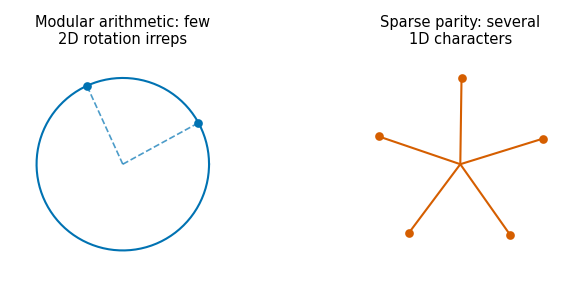

In [93]:
name = "fig1_isotypic_bottleneck"
if _fig_done(name):
    print(f"{name} already exists -- showing the cached version (set overwrite=True to regenerate).")
    from IPython.display import Image, display
    display(Image(filename=str(DIRS["figures"] / f"{name}.png")))
else:
    fig, axes = new_panel_fig(2)  # no suptitle here on purpose -- with per-panel
                                                 # titles already present, a figure-level suptitle
                                                 # has nowhere to sit without colliding with them;
                                                 # the caption above carries that framing instead
    theta = np.linspace(0, 2 * np.pi, 200)
    axes[0].plot(np.cos(theta), np.sin(theta), color=C_MODULAR, lw=1.0)
    for ang in [0.5, 2.0]:
        axes[0].plot([0, np.cos(ang)], [0, np.sin(ang)], "--", color=C_MODULAR, lw=0.8, alpha=0.7)
        axes[0].scatter([np.cos(ang)], [np.sin(ang)], color=C_MODULAR, zorder=3, s=10)
    axes[0].set_title("Modular arithmetic: few\n2D rotation irreps", fontsize=FS_TITLE)
    axes[0].set_xlim(-1.25, 1.25); axes[0].set_ylim(-1.25, 1.25); axes[0].set_aspect("equal"); axes[0].axis("off")

    n_arms = 5
    angs = np.linspace(0, 2 * np.pi, n_arms, endpoint=False) + 0.3
    for a in angs:
        axes[1].plot([0, np.cos(a)], [0, np.sin(a)], color=C_PARITY, lw=1.0)
        axes[1].scatter([np.cos(a)], [np.sin(a)], color=C_PARITY, zorder=3, s=10)
    axes[1].set_title("Sparse parity: several\n1D characters", fontsize=FS_TITLE)
    axes[1].set_xlim(-1.25, 1.25); axes[1].set_ylim(-1.25, 1.25); axes[1].set_aspect("equal"); axes[1].axis("off")

    _save_fig(fig, name)
    plt.show()


**Figure 2 -- rank collapse is task-symmetry-specific.** Panel A: modular arithmetic (pooled
across all primes/seeds). Panel B: sparse parity (pooled across all k/seeds). Same y-axis range on
both panels on purpose -- the contrast IS the result, and matching scales is what makes that
readable at a glance instead of requiring the reader to check two different axes.

  saved fig2_rank_collapse_contrast.pdf / .png


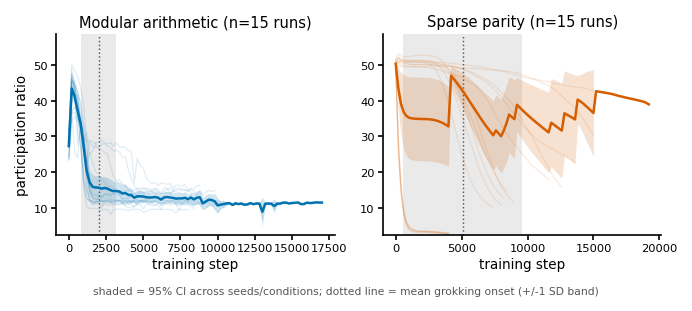

In [94]:
name = "fig2_rank_collapse_contrast"
if _fig_done(name):
    print(f"{name} already exists -- showing the cached version.")
    from IPython.display import Image, display
    display(Image(filename=str(DIRS["figures"] / f"{name}.png")))
else:
    modular_dfs = [df for k, df in all_logs.items() if k.startswith("modular_p") and "_wd" not in k and not df.empty]
    parity_dfs = [df for k, df in all_logs.items() if k.startswith("parity") and not df.empty]

    fig, axes = new_panel_fig(2)
    plot_trajectory_panel(axes[0], modular_dfs, "participation_ratio", C_MODULAR,
                           onset_fn=lambda d: _grok_onset(d, CONFIG["modular"]["grok_acc_threshold"]))
    plot_trajectory_panel(axes[1], parity_dfs, "participation_ratio", C_PARITY,
                           onset_fn=lambda d: _grok_onset(d, CONFIG["parity"]["grok_acc_threshold"]))

    y_all = pd.concat([d["participation_ratio"] for d in modular_dfs + parity_dfs]) if (modular_dfs or parity_dfs) else pd.Series([0, 1])
    ylim = (max(0, y_all.min() * 0.9), y_all.max() * 1.1)
    for ax in axes:
        ax.set_ylim(*ylim)
    style_axis(axes[0], "training step", "participation ratio", f"Modular arithmetic (n={len(modular_dfs)} runs)")
    style_axis(axes[1], "training step", "", f"Sparse parity (n={len(parity_dfs)} runs)")
    fig.text(0.5, -0.06, "shaded = 95% CI across seeds/conditions; dotted line = mean grokking onset (+/-1 SD band)",
              ha="center", fontsize=FS_ANNOT, color=C_NEUTRAL)
    _save_fig(fig, name)
    plt.show()


**Figure 3 -- H2 evidence.** Panel A: the recovered precursor (Walsh score, degree<=1, pooled
across k/seeds) on parity. Panel B: lead-time distributions by signal, both task families,
with the primary comparison's effect size and Bonferroni-adjusted significance annotated directly.
Panel C: the same parity runs' rank lead and Walsh lead, paired and connected per run -- Panel B's
aggregate can hide whether a single run's two signals actually agree in direction; this shows it
directly rather than assuming the aggregate speaks for every run.

  saved fig3_h2_evidence.pdf / .png


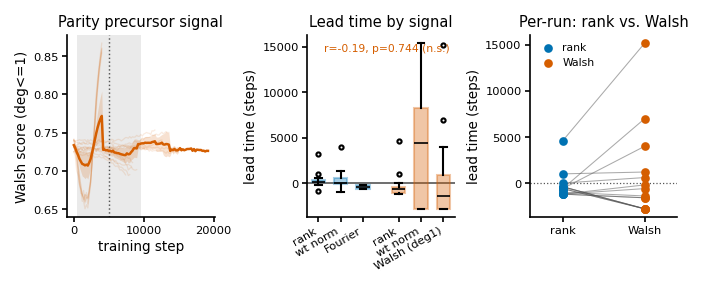

In [95]:
name = "fig3_h2_evidence"
if _fig_done(name):
    print(f"{name} already exists -- showing the cached version.")
    from IPython.display import Image, display
    display(Image(filename=str(DIRS["figures"] / f"{name}.png")))
else:
    fig, axes = new_panel_fig(3)
    plot_trajectory_panel(axes[0], parity_dfs, "walsh_score_deg1", C_PARITY,
                           onset_fn=lambda d: _grok_onset(d, CONFIG["parity"]["grok_acc_threshold"]))
    style_axis(axes[0], "training step", "Walsh score (deg<=1)",
               "Parity precursor signal")

    lead_cols_plot = [c for c in onset_df.columns
                       if c.startswith("lead_") and c != "lead_walsh_score"]  # drop the noisier degree-2 lead; keep everything else
    labels_map = {"lead_participation_ratio": "rank", "lead_weight_norm": "wt norm",
                  "lead_walsh_score_deg1": "Walsh (deg1)", "lead_fourier_conc": "Fourier"}
    positions, box_data, box_labels, box_colors = [], [], [], []
    pos = 0
    for kind, color in [("modular", C_MODULAR), ("parity", C_PARITY)]:
        sub = onset_df[onset_df.kind == kind]
        for col in lead_cols_plot:
            if col not in sub.columns:
                continue
            vals = sub[col].dropna().tolist()
            if not vals:
                continue
            box_data.append(vals); box_labels.append(labels_map.get(col, col.replace("lead_", "")))
            box_colors.append(color); positions.append(pos); pos += 1
        pos += 0.6  # gap between task families

    if box_data:
        bp = axes[1].boxplot(box_data, positions=positions, widths=0.6, patch_artist=True,
                              medianprops=dict(color="black", lw=0.8), flierprops=dict(markersize=2))
        for box, c in zip(bp["boxes"], box_colors):
            box.set_facecolor(c); box.set_alpha(0.35); box.set_edgecolor(c)
        axes[1].axhline(0, color=C_NEUTRAL, lw=0.8, zorder=0)
        axes[1].set_xticks(positions); axes[1].set_xticklabels(box_labels, fontsize=FS_TICK, rotation=30, ha="right")
        if h2_key in results:
            r = results[h2_key]
            stars = "*" if r["bonferroni_significant"] else "n.s."
            axes[1].annotate(f"r={r['rank_biserial_r']:.2f}, p={r['wilcoxon_p']:.3f} ({stars})",
                              xy=(0.97, 0.95), xycoords="axes fraction", fontsize=FS_ANNOT, ha="right", va="top",
                              color=C_PARITY)
    style_axis(axes[1], "", "lead time (steps)", "Lead time by signal")

    # Panel C: paired per-run comparison, rank lead vs Walsh lead -- same idea as your sample
    # Image 1B (erank vs clock, connected per seed): does the same RUN's rank and Walsh lead
    # agree in direction, or does the aggregate pattern in Panel B hide per-run disagreement?
    parity_onset = onset_df[onset_df.kind == "parity"].dropna(
        subset=["lead_participation_ratio", "lead_walsh_score_deg1"])
    if len(parity_onset) > 0:
        xs = [0] * len(parity_onset) + [1] * len(parity_onset)
        ys = list(parity_onset["lead_participation_ratio"]) + list(parity_onset["lead_walsh_score_deg1"])
        for _, row in parity_onset.iterrows():
            axes[2].plot([0, 1], [row["lead_participation_ratio"], row["lead_walsh_score_deg1"]],
                         color=C_NEUTRAL, lw=0.5, alpha=0.5, zorder=1)
        axes[2].scatter([0] * len(parity_onset), parity_onset["lead_participation_ratio"],
                         color=C_MODULAR, s=10, zorder=3, label="rank")
        axes[2].scatter([1] * len(parity_onset), parity_onset["lead_walsh_score_deg1"],
                         color=C_PARITY, s=10, zorder=3, label="Walsh")
        axes[2].axhline(0, color=C_NEUTRAL, lw=0.6, ls=":", zorder=0)
        axes[2].set_xlim(-0.4, 1.4); axes[2].set_xticks([0, 1]); axes[2].set_xticklabels(["rank", "Walsh"])
        axes[2].legend(fontsize=FS_LEGEND, loc="best", frameon=False, handletextpad=0.3, borderaxespad=0.3)
    else:
        axes[2].text(0.5, 0.5, "no paired data", ha="center", va="center", transform=axes[2].transAxes,
                      fontsize=FS_TICK, color=C_NEUTRAL)
    style_axis(axes[2], "", "lead time (steps)", "Per-run: rank vs. Walsh")

    _save_fig(fig, name)
    plt.show()


**Figure 4 -- H1 and the structure/timing dissociation.** Panel A: plateau rank vs. Fourier
concentration across the (now 3-prime) sweep, with Pearson r and p annotated on the plot. Panel B:
the weight-decay robustness check -- plateau rank stays flat while grokking timing shifts, the
dissociation the isotypic-dimension account specifically predicts and a pure-timing account does not.

  saved fig4_h1_and_dissociation.pdf / .png


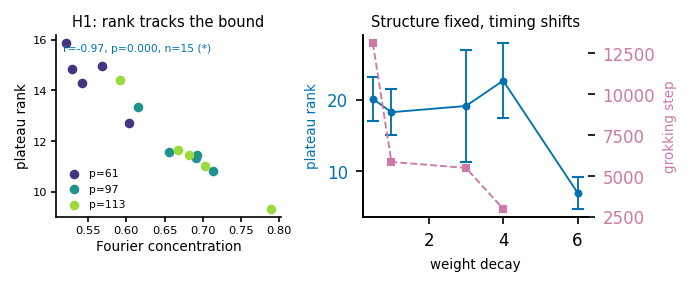

In [96]:
name = "fig4_h1_and_dissociation"
if _fig_done(name):
    print(f"{name} already exists -- showing the cached version.")
    from IPython.display import Image, display
    display(Image(filename=str(DIRS["figures"] / f"{name}.png")))
elif 'h1_df' in dir() and len(h1_df) > 0:
    fig, axes = new_panel_fig(2)
    primes_unique = sorted(h1_df["p"].unique())
    prime_colors = plt.cm.viridis(np.linspace(0.15, 0.85, max(len(primes_unique), 1)))
    for p_val, c in zip(primes_unique, prime_colors):
        sub = h1_df[h1_df["p"] == p_val]
        axes[0].scatter(sub["plateau_fourier_concentration"], sub["plateau_participation_ratio"],
                         color=c, s=13, label=f"p={p_val}", zorder=3)
    if len(h1_df) >= 3 and h1_df["plateau_participation_ratio"].std() > 0:
        r_val, p_val_stat = sstats.pearsonr(h1_df["plateau_fourier_concentration"], h1_df["plateau_participation_ratio"])
        stars = "*" if p_val_stat < 0.05 else "n.s."
        axes[0].annotate(f"r={r_val:.2f}, p={p_val_stat:.3f}, n={len(h1_df)} ({stars})",
                          xy=(0.03, 0.95), xycoords="axes fraction", fontsize=FS_ANNOT, va="top", color=C_MODULAR)
    axes[0].legend(fontsize=FS_LEGEND, loc="best", frameon=False, handletextpad=0.3, borderaxespad=0.3)
    style_axis(axes[0], "Fourier concentration", "plateau rank", "H1: rank tracks the bound")

    if 'robustness_df2' in dir() and len(robustness_df2) > 0:
        wds = sorted(robustness_df2["weight_decay"].unique())
        pr_means = [robustness_df2[robustness_df2.weight_decay == w]["plateau_participation_ratio"].mean() for w in wds]
        pr_stds = [robustness_df2[robustness_df2.weight_decay == w]["plateau_participation_ratio"].std() for w in wds]
        t_means = [robustness_df2[robustness_df2.weight_decay == w]["t_grok"].mean() for w in wds]
        have_timing = any(pd.notna(t) for t in t_means)

        axes[1].errorbar(wds, pr_means, yerr=pr_stds, color=C_MODULAR, marker="o", ms=2.8, lw=0.9,
                          capsize=3, label="plateau rank")
        axes[1].set_xlabel("weight decay", fontsize=FS_LABEL)
        axes[1].set_ylabel("plateau rank", fontsize=FS_LABEL, color=C_MODULAR)
        axes[1].tick_params(axis="y", labelcolor=C_MODULAR, labelsize=8)
        axes[1].tick_params(axis="x", labelsize=8)
        axes[1].spines["top"].set_visible(False)

        if have_timing:
            ax2b = axes[1].twinx()
            ax2b.plot(wds, t_means, color=C_ACCENT2, marker="s", ms=2.8, lw=0.9, ls="--", label="t_grok")
            ax2b.set_ylabel("grokking step", fontsize=FS_LABEL, color=C_ACCENT2)
            ax2b.tick_params(axis="y", labelcolor=C_ACCENT2, labelsize=8)
            axes[1].set_title("Structure fixed, timing shifts", fontsize=FS_TITLE, pad=4)
        else:
            axes[1].set_title("Structure vs. weight decay\n(no grok at this scale)", fontsize=FS_TITLE, pad=4)
    else:
        axes[1].text(0.5, 0.5, "robustness sweep not available", ha="center", va="center",
                      transform=axes[1].transAxes, fontsize=FS_TICK, color=C_NEUTRAL)

    _save_fig(fig, name)
    plt.show()
else:
    print("h1_df not available or empty -- run Section 8 first.")


**Figure 5 -- H1 across group families, reported honestly.** Panel A: predicted isotypic bound
vs. measured plateau rank for all three families (Z_p, S4, D4) on the same dimension axis. Both the
pooled correlation and the Z_p-only correlation are annotated together on purpose -- the pooled
number alone overstates the case, since S4 never converges and so contributes zero within-family
x-variance (it can only pull the pooled fit as a fixed point, not provide real within-family
evidence); D4's own within-family correlation is directionally positive but underpowered at n=5.
The Z_p-only number is the load-bearing evidence; see `h1_pooled_honesty_check.csv` for the full
pooled / pooled-excluding-S4 / within-family breakdown before quoting the pooled number alone.
Panel B: which irreps S4 actually ends up using, aggregated (mean +/- SD) across seeds at the
plateau -- the concrete, qualitative complement to Panel A's number.

  saved fig5_h1_nonabelian_generalization.pdf / .png


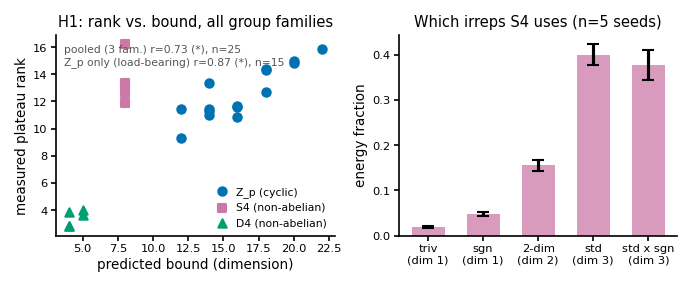

In [97]:
name = "fig5_h1_nonabelian_generalization"
if _fig_done(name):
    print(f"{name} already exists -- showing the cached version.")
    from IPython.display import Image, display
    display(Image(filename=str(DIRS["figures"] / f"{name}.png")))
elif 'pooled_h1_df' in dir() and len(pooled_h1_df) > 0:
    fig, axes = new_panel_fig(2)

    fam_style = {"Z_p (cyclic)": dict(color=C_MODULAR, marker="o"),
                 "S4 (non-abelian)": dict(color=C_ACCENT2, marker="s"),
                 "D4 (non-abelian)": dict(color=C_S4, marker="^")}
    for fam, sty in fam_style.items():
        sub = pooled_h1_df[pooled_h1_df.family == fam]
        if len(sub):
            axes[0].scatter(sub["predicted_bound"], sub["measured_rank"], s=16, label=fam,
                             zorder=3, **sty)
    # Annotate BOTH the pooled number and the load-bearing (Z_p-only) number together -- a bare
    # pooled r on its own overstates the case, since S4 contributes zero within-family variance
    # (see the Section 8 honesty check) and can only pull the pooled fit as a fixed point, not
    # provide real within-family evidence.
    if len(pooled_h1_df) >= 3 and pooled_h1_df["predicted_bound"].nunique() > 1:
        r_pool, p_pool = sstats.pearsonr(pooled_h1_df["predicted_bound"], pooled_h1_df["measured_rank"])
        stars_pool = "*" if p_pool < 0.05 else "n.s."
        annot_lines = [f"pooled (3 fam.) r={r_pool:.2f} ({stars_pool}), n={len(pooled_h1_df)}"]
        zp_sub = pooled_h1_df[pooled_h1_df.family == "Z_p (cyclic)"]
        if len(zp_sub) >= 3 and zp_sub["predicted_bound"].nunique() > 1:
            r_zp, p_zp = sstats.pearsonr(zp_sub["predicted_bound"], zp_sub["measured_rank"])
            stars_zp = "*" if p_zp < 0.05 else "n.s."
            annot_lines.append(f"Z_p only (load-bearing) r={r_zp:.2f} ({stars_zp}), n={len(zp_sub)}")
        axes[0].annotate("\n".join(annot_lines), xy=(0.03, 0.95), xycoords="axes fraction",
                          fontsize=FS_ANNOT, va="top", color=C_NEUTRAL)
    axes[0].legend(fontsize=FS_LEGEND, loc="best", frameon=False, handletextpad=0.3, borderaxespad=0.3)
    style_axis(axes[0], "predicted bound (dimension)", "measured plateau rank", "H1: rank vs. bound, all group families")

    s4_dfs = [df for k, df in all_logs.items() if k.startswith("s4_") and not df.empty]
    energy_cols = [c for c in (s4_dfs[0].columns if s4_dfs else []) if c.startswith("energy_")]
    if s4_dfs and energy_cols:
        plateau_energies = {c.replace("energy_", ""): [] for c in energy_cols}
        for df in s4_dfs:
            tail = df.tail(max(1, len(df) // 5))
            for c in energy_cols:
                plateau_energies[c.replace("energy_", "")].append(tail[c].mean())
        irrep_order = sorted(plateau_energies, key=lambda k: S4_IRREP_DIMS[k])
        means = [np.mean(plateau_energies[k]) for k in irrep_order]
        stds = [np.std(plateau_energies[k]) for k in irrep_order]
        short_names = {"trivial": "triv", "sign": "sgn", "two_dim": "2-dim", "standard": "std",
                       "standard_sign": "std x sgn"}
        labels = [f"{short_names[k]}\n(dim {S4_IRREP_DIMS[k]})" for k in irrep_order]
        axes[1].bar(range(len(irrep_order)), means, yerr=stds, color=C_ACCENT2, alpha=0.75,
                    capsize=3, width=0.6)
        axes[1].set_xticks(range(len(irrep_order))); axes[1].set_xticklabels(labels, fontsize=FS_TICK)
        style_axis(axes[1], "", "energy fraction", f"Which irreps S4 uses (n={len(s4_dfs)} seeds)")
    else:
        axes[1].text(0.5, 0.5, "no S4 runs available", ha="center", va="center",
                      transform=axes[1].transAxes, fontsize=FS_TICK, color=C_NEUTRAL)

    _save_fig(fig, name)
    plt.show()
else:
    print("pooled_h1_df not available or empty -- run Section 8's pooled H1 cell first.")


**Figure 6 -- the weight-decay clock as an honest lower bound.** Panel A: $T^*_{grok}$ vs. the
unfitted clock $\tau_c$, colored by task family, with the y=x line marking where the lower bound
would be exactly tight -- points should sit *above* it, not on it (this is deliberately not your
paper's calibrated $\bar c \tau_c$ predictor; see the Section 8 note on what is and isn't being
claimed here). Panel B: the multiplier $T^*/\tau_c$ by family, showing how loose or tight the
bound is in practice.

  saved fig6_weight_decay_clock.pdf / .png


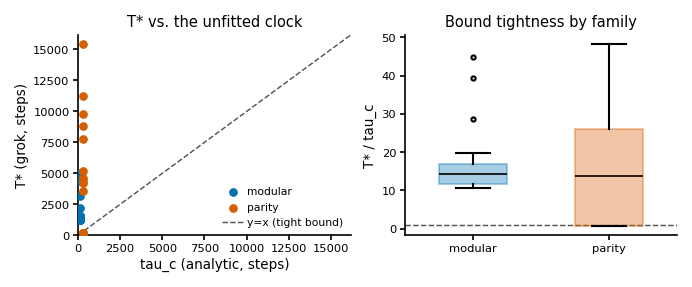

In [98]:
name = "fig6_weight_decay_clock"
if _fig_done(name):
    print(f"{name} already exists -- showing the cached version.")
    from IPython.display import Image, display
    display(Image(filename=str(DIRS["figures"] / f"{name}.png")))
elif 'clock_df' in dir() and len(clock_df) > 0:
    fig, axes = new_panel_fig(2)
    fam_colors = {"modular": C_MODULAR, "parity": C_PARITY, "S4": C_S4}
    for fam, color in fam_colors.items():
        sub = clock_df[clock_df.family == fam]
        if len(sub):
            axes[0].scatter(sub["tau_c"], sub["t_star"], s=10, color=color, label=fam, zorder=3)
    lims = [0, max(clock_df["tau_c"].max(), clock_df["t_star"].max()) * 1.05]
    axes[0].plot(lims, lims, "--", color=C_NEUTRAL, lw=0.7, zorder=1, label="y=x (tight bound)")
    axes[0].set_xlim(lims); axes[0].set_ylim(lims)
    axes[0].legend(fontsize=FS_LEGEND, loc="best", frameon=False, handletextpad=0.3, borderaxespad=0.3)
    style_axis(axes[0], "tau_c (analytic, steps)", "T* (grok, steps)", "T* vs. the unfitted clock")

    fam_list = [f for f in fam_colors if (clock_df.family == f).any()]
    positions = list(range(len(fam_list)))
    ratios = [clock_df[clock_df.family == f]["ratio"].values for f in fam_list]
    bp = axes[1].boxplot(ratios, positions=positions, widths=0.5, patch_artist=True,
                          medianprops=dict(color="black", lw=0.8), flierprops=dict(markersize=2))
    for box, f in zip(bp["boxes"], fam_list):
        box.set_facecolor(fam_colors[f]); box.set_alpha(0.35); box.set_edgecolor(fam_colors[f])
    axes[1].axhline(1.0, color=C_NEUTRAL, lw=0.7, ls="--", zorder=0)
    axes[1].set_xticks(positions); axes[1].set_xticklabels(fam_list, fontsize=FS_TICK)
    style_axis(axes[1], "", "T* / tau_c", "Bound tightness by family")

    _save_fig(fig, name)
    plt.show()
else:
    print("clock_df not available or empty -- run Section 8's clock cell first.")


**Supplementary figure -- failure-case diagnostic** (only generated if Section 11 found a run
worth inspecting; not one of the four numbered results figures, kept for the appendix / rebuttal
material rather than the main body given the 9-page budget).

  saved figS1_failure_case_diagnostic.pdf / .png


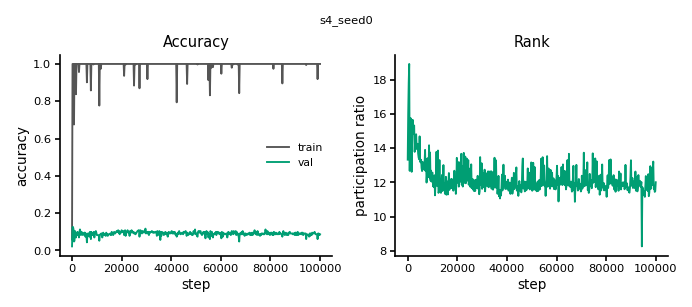

Diagnostic plot saved for s4_seed0.


In [99]:
name = "figS1_failure_case_diagnostic"
if _fig_done(name):
    print(f"{name} already exists -- showing the cached version.")
    from IPython.display import Image, display
    display(Image(filename=str(DIRS["figures"] / f"{name}.png")))
elif failures["s4_never_grokked"] or failures["never_grokked"] or failures["non_positive_lead"]:
    # S4 checked first: a network stuck at chance accuracy is the most informative failure to
    # show, more so than a run with a merely negative lead time -- don't bury it behind others.
    if failures["s4_never_grokked"]:
        _worst_id = failures["s4_never_grokked"][0]["run_id"]
    elif failures["never_grokked"]:
        _worst_id = failures["never_grokked"][0]["run_id"]
    else:
        _worst_id = failures["non_positive_lead"][0]["run_id"]
    df = all_logs[_worst_id]
    fig, axes = new_panel_fig(2)
    if "modular" in _worst_id:
        _c = C_MODULAR
    elif "s4" in _worst_id:
        _c = C_S4
    else:
        _c = C_PARITY
    axes[0].plot(df["step"], df["train_acc"], color=C_NEUTRAL, lw=0.9, label="train")
    axes[0].plot(df["step"], df["val_acc"], color=_c, lw=0.9, label="val")
    axes[0].legend(fontsize=FS_LEGEND, frameon=False)
    style_axis(axes[0], "step", "accuracy", "Accuracy")
    axes[1].plot(df["step"], df["participation_ratio"], color=_c, lw=0.9)
    style_axis(axes[1], "step", "participation ratio", "Rank")
    fig.suptitle(_worst_id, fontsize=FS_TICK, y=1.05)
    _save_fig(fig, name)
    plt.show()
    print(f"Diagnostic plot saved for {_worst_id}.")
else:
    print("No failure case to plot.")


## Section 15 -- Results tables

Every table already saved as `.csv` in Section 8-11 gets a matching `.tex` (booktabs-style) version
here for direct inclusion in the paper.

In [100]:
# Plain-text headers deliberately -- LaTeX math mode ($...$) inside a header string collides with
# pandas' escape=True (needed for the underscores in the DATA, e.g. run/signal names) and comes out
# double-escaped garbage. Plain text is what's actually guaranteed to render correctly.
COLUMN_LABELS = {
    "signal": "Signal", "run_id": "Run", "n": "n", "k": "k", "seed": "Seed",
    "wilcoxon_p": "Wilcoxon p", "sign_test_p": "Sign test p",
    "n_positive": "n (positive)", "prop_positive": "Prop. positive",
    "rank_biserial_r": "Effect size r", "ci_lo": "CI lo", "ci_mean": "Mean", "ci_hi": "CI hi",
    "bonferroni_significant": "Sig. (Bonf.)", "p": "Prime p", "d_model": "Model dim.",
    "plateau_participation_ratio": "Plateau rank", "plateau_fourier_concentration": "Fourier conc.",
    "degree_bound": "Degree bound", "mean": "Mean lead", "std": "Std. dev.", "count": "n",
    "mean_plateau_pr": "Mean plateau rank", "mean_lead_walsh": "Mean Walsh lead", "n_runs": "Runs",
    "weight_decay": "Weight decay", "t_grok": "Grokking step", "noise": "Noise (std)",
    "true_isotypic_dim": "True dim.", "participation_ratio": "Part. ratio",
    "entropy_rank": "Entropy rank", "rank99": "Rank99", "sigma1": "Top singular value",
    "config": "Config", "probe_size": "Probe size", "oos_score_on_pure_noise": "OOS score (noise)",
    "lead_mean_ci": "Mean lead [95% CI]", "p_values": "p (Wilcoxon / sign)",
    "family": "Group family", "predicted_bound": "Predicted bound", "measured_rank": "Measured rank",
    "tau_c": "tau_c (steps)", "t_star": "T* (steps)", "ratio": "T*/tau_c",
    "group": "Group", "grokked": "Grokked", "n_seeds": "Seeds", "n_grokked": "N grokked",
    "grok_rate": "Grok rate", "mean_final_val_acc": "Mean final val acc",
    "rho": "rho", "sum": "N holding", "count": "N total", "frac_holding": "Fraction holding",
    "clock_ratio": "T*/tau_c",
    "test": "Comparison", "r": "r", "p": "p", "caveat": "Caveat",
}

# Human-readable signal names for the H2 table -- "parity:lead_walsh_score_deg1" means nothing to
# a reader without cross-referencing the code; name it for what it actually is.
SIGNAL_LABELS = {
    "modular:lead_participation_ratio": "Rank (modular)",
    "modular:lead_weight_norm": "Weight norm (modular)",
    "modular:lead_fourier_conc": "Fourier concentration (modular)",
    "parity:lead_participation_ratio": "Rank (parity)",
    "parity:lead_weight_norm": "Weight norm (parity)",
    "parity:lead_walsh_score": "Walsh score, deg<=2 (parity)",
    "parity:lead_walsh_score_deg1": "Walsh score, deg<=1 (parity)",
}

def df_to_latex_booktabs(df, caption, label, float_fmt="%.3g"):
    # index=False is deliberate: every meaningful identifier (signal, run_id, ...) is already an
    # explicit column by the time a table reaches this function, so the pandas-internal row index
    # (0,1,2,... after a CSV round-trip) would otherwise print as a meaningless blank leading column.
    df = df.copy()
    if "signal" in df.columns:
        df["signal"] = df["signal"].map(lambda s: SIGNAL_LABELS.get(s, s))
    df = df.rename(columns=COLUMN_LABELS)
    return df.to_latex(index=False, caption=caption, label=label, float_format=float_fmt,
                        escape=True, na_rep="--")

print("df_to_latex_booktabs ready (index-free, human-readable headers and signal names).")


df_to_latex_booktabs ready (index-free, human-readable headers and signal names).


**H2's raw table has 12 columns** -- reproducible and complete, but too wide for a print table.
This builds the paper-ready condensed version alongside it: combined "mean [95% CI]" instead of three
separate columns, both p-values folded into one "Wilcoxon / sign" column so agreement between the two
tests is visible at a glance instead of requiring a cross-reference.

In [101]:
h2_csv_path = DIRS["tables"] / "h2_lead_time_significance.csv"
if h2_csv_path.exists():
    _h2_raw = pd.read_csv(h2_csv_path)
    h2_compact = pd.DataFrame({
        "signal": _h2_raw["signal"],
        "n": _h2_raw["n"].astype("Int64"),
        "lead_mean_ci": [f"{m:.0f} [{lo:.0f}, {hi:.0f}]" for m, lo, hi in
                          zip(_h2_raw["ci_mean"], _h2_raw["ci_lo"], _h2_raw["ci_hi"])],
        "p_values": [f"{w:.3f} / {s:.3f}" for w, s in zip(_h2_raw["wilcoxon_p"], _h2_raw["sign_test_p"])],
        "rank_biserial_r": _h2_raw["rank_biserial_r"].round(2),
        "bonferroni_significant": _h2_raw["bonferroni_significant"].map({True: "yes", False: "no"}),
    })
    h2_compact.to_csv(DIRS["tables"] / "h2_lead_time_significance_compact.csv", index=False)
    print(h2_compact.to_string(index=False))
else:
    print("h2_lead_time_significance.csv not found -- run Section 8 first.")


                          signal  n      lead_mean_ci      p_values  rank_biserial_r bonferroni_significant
modular:lead_participation_ratio 15     387 [27, 880] 0.015 / 0.059             0.67                     no
        modular:lead_weight_norm 15   400 [-80, 1027] 0.098 / 0.696             0.44                     no
       modular:lead_fourier_conc 15 -400 [-480, -320] 1.000 / 1.000            -1.00                     no
 parity:lead_participation_ratio 15  -253 [-813, 587] 0.971 / 1.000            -0.57                     no
         parity:lead_weight_norm 15 4067 [1200, 6987] 0.005 / 0.151             0.75                    yes
         parity:lead_walsh_score 15  -40 [-867, 1000] 0.819 / 0.982            -0.27                     no
    parity:lead_walsh_score_deg1 15 573 [-1507, 3307] 0.744 / 0.941            -0.19                     no


In [102]:
_table_specs = [
    ("h2_lead_time_significance_compact.csv", "h2_lead_time_significance",
     "Lead time and significance by signal and task family (Bonferroni-adjusted across all "
     "signal/task comparisons).", "tab:h2"),
    ("h1_rank_vs_bound.csv", "h1_rank_vs_bound",
     "Plateau participation ratio vs. Fourier concentration across the prime sweep.", "tab:h1"),
    ("h1_pooled_cross_family.csv", "h1_pooled_cross_family",
     "H1 pooled across Z_p, S4 and D4: predicted (dimension-weighted) bound vs. measured plateau rank, "
     "raw per-run data.", "tab:h1pooled"),
    ("h1_pooled_honesty_check.csv", "h1_pooled_honesty_check",
     "H1 pooled correlation, reported with the caveat a bare pooled number hides: pooled, pooled "
     "excluding S4, and within each family separately. Read this before quoting the pooled r alone.",
     "tab:h1honesty"),
    ("weight_decay_clock.csv", "weight_decay_clock",
     "The unfitted weight-decay clock as a lower bound on T*, by task family (not the calibrated "
     "predictor from the NeurIPS 2026 paper -- see the Section 8 note).", "tab:clock"),
    ("nonabelian_wd_grid_summary.csv", "nonabelian_wd_grid_summary",
     "Grokking rate by group and weight decay: disentangling whether S4's non-convergence is "
     "about group size or the weight-decay recipe.", "tab:nonabeliangrid"),
    ("clock_rho_sensitivity.csv", "clock_rho_sensitivity",
     "Robustness of the clock lower bound to the choice of rho (fraction holding, by family).",
     "tab:rhosens"),
    ("ablation_walsh_degree.csv", "ablation_walsh_degree",
     "Ablation: Walsh score degree bound vs. mean lead time.", "tab:ablation_degree"),
    ("ablation_k_sweep.csv", "ablation_k_sweep",
     "Ablation: pattern across sparsity level k.", "tab:ablation_k"),
    ("robustness_wd_sensitivity.csv", "robustness_wd_sensitivity",
     "Weight-decay sensitivity: plateau rank vs. grokking timing.", "tab:robustness"),
    ("metric_robustness_check.csv", "metric_robustness_check",
     "Rank-metric sensitivity to ambient noise at a known true isotypic dimension.", "tab:metric_robustness"),
    ("h2_lead_time_significance.csv", "h2_lead_time_significance_full",
     "H2, full statistics (supplementary -- Table~\\ref{tab:h2} is the condensed main-text version).",
     "tab:h2full"),
]

written = []
for csv_name, tex_stem, caption, label in _table_specs:
    csv_path = DIRS["tables"] / csv_name
    if not csv_path.exists():
        print(f"  (skip) {csv_name} not found -- run the corresponding section first.")
        continue
    df = pd.read_csv(csv_path)
    tex = df_to_latex_booktabs(df, caption, label)
    tex_path = DIRS["tables"] / f"{tex_stem}.tex"
    with open(tex_path, "w") as f:
        f.write(tex)
    written.append(tex_stem)

print(f"\nWrote {len(written)} LaTeX tables: {written}")



Wrote 12 LaTeX tables: ['h2_lead_time_significance', 'h1_rank_vs_bound', 'h1_pooled_cross_family', 'h1_pooled_honesty_check', 'weight_decay_clock', 'nonabelian_wd_grid_summary', 'clock_rho_sensitivity', 'ablation_walsh_degree', 'ablation_k_sweep', 'robustness_wd_sensitivity', 'metric_robustness_check', 'h2_lead_time_significance_full']


## Section 16 -- Consolidated logging

Environment info and config were already exported in Section 1-2. This cell concatenates every
per-run metric log into one master CSV and writes a manifest of every artifact produced so far.

In [103]:
master_rows = []
for run_id, df in all_logs.items():
    if df.empty:
        continue
    d = df.copy()
    d.insert(0, "run_id", run_id)
    master_rows.append(d)

if master_rows:
    master_log = pd.concat(master_rows, ignore_index=True)
    master_log.to_csv(DIRS["logs"] / "master_metric_log.csv", index=False)
    print(f"Master log: {len(master_log)} rows across {len(master_rows)} runs -> "
          f"outputs/logs/master_metric_log.csv")
else:
    print("No run logs to consolidate yet.")

with open(DIRS["logs"] / "run_times.json", "w") as f:
    json.dump(RUN_TIMES, f, indent=2)
with open(DIRS["logs"] / "seeds_used.json", "w") as f:
    json.dump({"global_seed": 0, "per_run_seeds": CONFIG["seeds"]}, f, indent=2)

print("Logged: run_times.json, seeds_used.json, environment.json, config.json (already saved), "
      "performance_profile.json (already saved).")


Master log: 6329 rows across 40 runs -> outputs/logs/master_metric_log.csv
Logged: run_times.json, seeds_used.json, environment.json, config.json (already saved), performance_profile.json (already saved).


## Section 21 -- Validation checks

Verifies every artifact category exists before declaring the run complete. Where a check fails, it
is reported explicitly rather than silently ignored -- automatic regeneration is not attempted here
(most missing artifacts require rerunning a compute cell above, which this cell does not do on your
behalf), but the message says exactly what's missing and which section produces it.

In [104]:
checks = [
    ("dataset cache",      any(DIRS["cache_datasets"].glob("*.pt")),        "Section 6"),
    ("metric logs cached", any(DIRS["cache_metrics"].glob("*.csv")),        "Section 7"),
    ("model checkpoints",  any(DIRS["checkpoints"].glob("*/last_model.pt")),"Section 7"),
    ("config exported",    (DIRS["configs"] / "config.json").exists(),      "Section 2"),
    ("environment exported", (DIRS["environment"] / "environment.json").exists(), "Section 1"),
    ("onset/lead metrics", (DIRS["metrics"] / "onset_and_lead_times.csv").exists(), "Section 8"),
    ("H1/H2 tables",       (DIRS["tables"] / "h2_lead_time_significance.csv").exists(), "Section 8"),
    ("H1 pooled (S4) table", (DIRS["tables"] / "h1_pooled_cross_family.csv").exists(), "Section 8"),
    ("H1 pooled honesty check", (DIRS["tables"] / "h1_pooled_honesty_check.csv").exists(), "Section 8"),
    ("weight-decay clock table", (DIRS["tables"] / "weight_decay_clock.csv").exists(), "Section 8"),
    ("non-abelian wd grid table", (DIRS["tables"] / "nonabelian_wd_grid.csv").exists(), "Section 8"),
    ("clock rho-sensitivity table", (DIRS["tables"] / "clock_rho_sensitivity.csv").exists(), "Section 8"),
    ("S4 metric sanity check", (DIRS["tables"] / "s4_metric_sanity_check.csv").exists(), "Section 4.3"),
    ("ablation tables",    (DIRS["tables"] / "ablation_k_sweep.csv").exists(), "Section 9"),
    ("robustness table",   (DIRS["tables"] / "robustness_wd_sensitivity.csv").exists(), "Section 10"),
    ("failure analysis",   (DIRS["metrics"] / "failure_analysis.json").exists(), "Section 11"),
    ("performance profile",(DIRS["environment"] / "performance_profile.json").exists(), "Section 12"),
    ("figures (6 core)",   all((DIRS["figures"] / f"{n}.pdf").exists() for n in
                                ["fig1_isotypic_bottleneck", "fig2_rank_collapse_contrast",
                                 "fig3_h2_evidence", "fig4_h1_and_dissociation",
                                 "fig5_h1_nonabelian_generalization", "fig6_weight_decay_clock"]), "Section 14"),
    ("LaTeX tables",       any(DIRS["tables"].glob("*.tex")),               "Section 15"),
    ("master log",         (DIRS["logs"] / "master_metric_log.csv").exists(), "Section 16"),
]

print(f"{'CHECK':32s} {'STATUS':8s} {'PRODUCED BY'}")
all_ok = True
for name, ok, source in checks:
    status = "OK" if ok else "MISSING"
    if not ok:
        all_ok = False
    print(f"{name:32s} {status:8s} {source}")

print("\n" + ("All checks passed." if all_ok else
              "Some artifacts are missing -- re-run the referenced section(s) above, then re-run this cell."))


CHECK                            STATUS   PRODUCED BY
dataset cache                    OK       Section 6
metric logs cached               OK       Section 7
model checkpoints                OK       Section 7
config exported                  OK       Section 2
environment exported             OK       Section 1
onset/lead metrics               OK       Section 8
H1/H2 tables                     OK       Section 8
H1 pooled (S4) table             OK       Section 8
H1 pooled honesty check          OK       Section 8
weight-decay clock table         OK       Section 8
non-abelian wd grid table        OK       Section 8
clock rho-sensitivity table      OK       Section 8
S4 metric sanity check           OK       Section 4.3
ablation tables                  OK       Section 9
robustness table                 OK       Section 10
failure analysis                 OK       Section 11
performance profile              OK       Section 12
figures (6 core)                 OK       Section 14
LaTe

## Section 22 -- Final summary, packaging, and download

Zips `outputs/` and triggers a download appropriate to the detected runtime: `google.colab.files`
on Colab, or a plain confirmation on Kaggle (where `/kaggle/working/outputs.zip` is automatically
offered for download from the notebook's Output tab -- no explicit download call exists on Kaggle).

In [105]:
import shutil

print("=" * 70)
print("EXPERIMENT SUMMARY")
print("=" * 70)
print(f"Runtime      : {ENV_INFO['runtime']}  |  device: {DEVICE}  |  GPU: {ENV_INFO['gpu_name']}")
print(f"Total runs   : {len(all_logs)}  |  total training time: {sum(RUN_TIMES.values()):.1f}s")
print(f"Params       : modular={N_PARAMS.get('modular')}  parity={N_PARAMS.get('parity')}  "
      f"s4={N_PARAMS.get('s4')}  d4={N_PARAMS.get('d4')}")

if 'results' in dir() and h2_key in results:
    r = results[h2_key]
    print(f"\nH2 (walsh_score_deg1 leads grokking on parity): mean lead {r['ci_mean']:.0f} steps, "
          f"95% CI [{r['ci_lo']:.0f}, {r['ci_hi']:.0f}], Bonferroni-significant: {r['bonferroni_significant']}")
if 'h1_df' in dir() and len(h1_df) >= 3:
    print(f"H1 (rank tracks isotypic bound, not d_model): see fig4_h1_and_dissociation.pdf and h1_rank_vs_bound.csv")
if 'h1_honesty_df' in dir() and len(h1_honesty_df) > 0:
    _zp_row = h1_honesty_df[h1_honesty_df.test == "within Z_p (cyclic) only"]
    _pool_row = h1_honesty_df[h1_honesty_df.test == "pooled (Z_p + S4 + D4)"]
    _zp_str = f"r={_zp_row['r'].iloc[0]:.3f} (p={_zp_row['p'].iloc[0]:.4f})" if len(_zp_row) and _zp_row['r'].iloc[0] is not None else "n/a"
    _pool_str = f"r={_pool_row['r'].iloc[0]:.3f} (p={_pool_row['p'].iloc[0]:.4f})" if len(_pool_row) and _pool_row['r'].iloc[0] is not None else "n/a"
    print(f"H1, load-bearing evidence (Z_p only, n=15): {_zp_str}")
    print(f"H1, pooled across all 3 families (n={len(pooled_h1_df) if 'pooled_h1_df' in dir() else '?'}, "
          f"see h1_pooled_honesty_check.csv for the within/pooled breakdown before quoting this alone): {_pool_str}")
    print("  -- see fig5_h1_nonabelian_generalization.pdf and h1_pooled_cross_family.csv")
if 'grid_df' in dir() and len(grid_df) > 0:
    _d4_ok = grid_df[grid_df.group == "D4"]["grokked"].any()
    _s4_ok = grid_df[grid_df.group == "S4"]["grokked"].any()
    print(f"Non-abelian disentangling grid: D4 grokked at any tested wd = {_d4_ok}, "
          f"S4 grokked at any tested wd = {_s4_ok} -- see nonabelian_wd_grid_summary.csv")
if 'clock_df' in dir() and len(clock_df) > 0:
    _n_hold = (clock_df["ratio"] > 1).sum()
    print(f"Weight-decay clock lower bound: holds in {_n_hold}/{len(clock_df)} runs -- "
          f"see fig6_weight_decay_clock.pdf and weight_decay_clock.csv")

print(f"\nOutput directory: {OUT.resolve()}")
print("\nGenerated artifacts:")
for f in sorted(OUT.rglob("*")):
    if f.is_file():
        print(f"  {f.relative_to(OUT)}  ({f.stat().st_size} bytes)")

# --- zip everything ---
zip_path = Path("outputs.zip")
if zip_path.exists():
    zip_path.unlink()
shutil.make_archive("outputs", "zip", root_dir=".", base_dir="outputs")
print(f"\nCreated {zip_path.resolve()} ({zip_path.stat().st_size / 1e6:.2f} MB)")

# --- platform-aware download ---
if ENV_INFO["runtime"] == "colab":
    from google.colab import files
    print("\nRuntime is Colab -- triggering browser download of outputs.zip ...")
    files.download(str(zip_path))
elif ENV_INFO["runtime"] == "kaggle":
    working_copy = Path("/kaggle/working/outputs.zip")
    if zip_path.resolve() == working_copy.resolve():
        # Kaggle's own working directory already IS /kaggle/working -- zip_path (relative
        # "outputs.zip") resolves to the exact same file as working_copy on Kaggle specifically,
        # so copying one onto the other raises shutil.SameFileError. Nothing to do; it's already there.
        print(f"\nRuntime is Kaggle -- outputs.zip is already at {working_copy} (this IS the "
              f"working directory on Kaggle). Download it from the notebook's Output/Data pane "
              f"after committing the run (Kaggle has no in-notebook download call).")
    elif working_copy.parent.exists():
        shutil.copy(zip_path, working_copy)
        print(f"\nRuntime is Kaggle -- copied to {working_copy}. "
              f"Download it from the notebook's Output/Data pane after committing the run "
              f"(Kaggle has no in-notebook download call).")
    else:
        print("\nRuntime detected as Kaggle but /kaggle/working is not present -- "
              f"outputs.zip is at {zip_path.resolve()}.")
else:
    print(f"\nLocal/unknown runtime -- outputs.zip is at {zip_path.resolve()}, no browser download triggered.")

print("\n" + "=" * 70)
print("DONE.")
print("=" * 70)


EXPERIMENT SUMMARY
Runtime      : kaggle  |  device: cuda  |  GPU: Tesla T4
Total runs   : 40  |  total training time: 15205.3s
Params       : modular=214656  parity=8602  s4=205184  d4=201088

H2 (walsh_score_deg1 leads grokking on parity): mean lead 573 steps, 95% CI [-1507, 3307], Bonferroni-significant: False
H1 (rank tracks isotypic bound, not d_model): see fig4_h1_and_dissociation.pdf and h1_rank_vs_bound.csv
H1, load-bearing evidence (Z_p only, n=15): r=0.866 (p=0.0000)
H1, pooled across all 3 families (n=25, see h1_pooled_honesty_check.csv for the within/pooled breakdown before quoting this alone): r=0.726 (p=0.0000)
  -- see fig5_h1_nonabelian_generalization.pdf and h1_pooled_cross_family.csv
Non-abelian disentangling grid: D4 grokked at any tested wd = False, S4 grokked at any tested wd = False -- see nonabelian_wd_grid_summary.csv
Weight-decay clock lower bound: holds in 25/30 runs -- see fig6_weight_decay_clock.pdf and weight_decay_clock.csv

Output directory: /kaggle/worki